In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio
from conformer import Conformer


In [2]:
TARGET_SR = 16000

class AudioListDataset(Dataset):
    def __init__(self, X, y, target_sr=TARGET_SR):
        """
        X: list of (np_array, sample_rate)
        y: list/array of int labels (0 or 1)
        """
        self.X = X
        self.y = np.array(y, dtype=np.int64)
        self.target_sr = target_sr

        # torchaudio modules
        self.resampler = None  # create lazily per sample_rate
        self.melspec = torchaudio.transforms.MelSpectrogram(
            sample_rate=target_sr,
            n_fft=400,
            hop_length=160,
            n_mels=80,
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)

    def _ensure_resampler(self, sr):
        if self.resampler is None or self.resampler.orig_freq != sr:
            self.resampler = torchaudio.transforms.Resample(
                orig_freq=sr,
                new_freq=self.target_sr,
            )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        waveform_np, sr = self.X[idx]        # waveform_np: (num_samples,)
        label = int(self.y[idx])

        # to tensor, shape [1, num_samples]
        waveform = torch.from_numpy(waveform_np).float().unsqueeze(0)

        # resample if needed
        if sr != self.target_sr:
            self._ensure_resampler(sr)
            waveform = self.resampler(waveform)

        # [1, T] -> [n_mels, time]
        mel = self.melspec(waveform)                # [80, time]
        mel_db = self.amplitude_to_db(mel)          # log-mel
        mel_db = mel_db.squeeze(0).transpose(0, 1)  # [time, 80]

        return mel_db, label

from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """
    batch: list of (features[T, 80], label)
    """
    feats, labels = zip(*batch)

    lengths = torch.LongTensor([f.shape[0] for f in feats])          # T for each sample
    padded = pad_sequence(feats, batch_first=True)                   # [B, T_max, 80]
    labels = torch.LongTensor(labels)                                # [B]

    return padded, lengths, labels


In [3]:
class ConformerClassifier(nn.Module):
    def __init__(self,
                 num_classes=2,
                 input_dim=80,
                 encoder_dim=128,
                 num_encoder_layers=4):
        super().__init__()
        self.backbone = Conformer(
            num_classes=num_classes,   # per-frame output dim
            input_dim=input_dim,
            encoder_dim=encoder_dim,
            num_encoder_layers=num_encoder_layers,
        )

    def forward(self, x, lengths):
        """
        x: [B, T, 80]
        lengths: [B]
        returns: [B, 2] logits per clip
        """
        frame_logits, out_lengths = self.backbone(x, lengths)  # [B, T, 2]

        B, T, C = frame_logits.shape
        device = frame_logits.device

        # build mask for valid frames (T can shrink inside the model; use out_lengths)
        t_idx = torch.arange(T, device=device).unsqueeze(0).expand(B, T)  # [B, T]
        mask = t_idx < out_lengths.unsqueeze(1)                           # [B, T]

        # average over time (masked)
        mask = mask.unsqueeze(-1)                                         # [B, T, 1]
        masked_logits = frame_logits * mask
        sum_logits = masked_logits.sum(dim=1)                             # [B, 2]
        denom = out_lengths.clamp(min=1).unsqueeze(1).to(frame_logits.dtype)
        clip_logits = sum_logits / denom

        return clip_logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model = ConformerClassifier(
    num_classes=2,
    input_dim=80,
    encoder_dim=128,
    num_encoder_layers=4,
).to(device)


Device: cuda


In [4]:
import numpy as np
import scipy.signal as signal
import random
from typing import List, Tuple, Optional

class RawBoost:
    """
    Implementation of RawBoost: A Raw Data Boosting and Augmentation Method 
    Applied to Automatic Speaker Verification Anti-Spoofing.
    
    Ref: Tak et al., ICASSP 2022
    """
    
    def __init__(self, algo_id: int = 1):
        """
        Args:
            algo_id (int): 
                1 = Linear and non-linear convolutive noise
                2 = Impulsive signal-dependent additive noise
                3 = Stationary signal-independent additive noise
                4 = Combination (1) + (2) (Best result in paper)
        """
        self.algo_id = algo_id

    # =========================================================================
    # Helper: Filter Generation (Section 3.1)
    # =========================================================================
    def _design_notch_filter(self, num_taps: int, fs: int) -> np.ndarray:
        """
        Designs a FIR filter with random notch characteristics.
        According to paper: N_notch random center freqs, filter widths, etc.
        """
        # Paper Table 1 ranges
        n_notch = random.randint(1, 5) 
        
        # Initialize filter as a Dirac delta (pass-all)
        a = np.zeros(num_taps)
        a[num_taps // 2] = 1.0
        
        # We create multiple notch filters and convolve them (cascade them)
        # Or summing them as per Eq 1 implementation details. 
        # The paper implies a single FIR defined by window method combining these notches.
        # Here we iteratively convolve notch filters to create the complex response.
        
        final_filter = np.zeros(num_taps)
        final_filter[num_taps // 2] = 1.0

        for _ in range(n_notch):
            # Randomized parameters based on Table 1
            # Frequencies are normalized. Paper uses [0, 1] for Nyquist? 
            # Fig 2 shows normalized freq 0.0 to 0.5. Assuming 0.5 is Nyquist.
            
            f_c = random.uniform(0.02, 0.48) # Avoiding edges
            f_w = random.uniform(0.01, 0.05) # Bandwidth
            
            # Create a notch filter using firwin
            # 2 * f_c because firwin expects 0-1 where 1 is Nyquist
            freq_low = 2 * (f_c - f_w/2)
            freq_high = 2 * (f_c + f_w/2)
            
            if freq_low <= 0: freq_low = 0.001
            if freq_high >= 1: freq_high = 0.999
            
            # Simple bandstop
            b = signal.firwin(num_taps, [freq_low, freq_high], pass_zero=True)
            
            # Gain variation (g_cn in Eq 1)
            g_cn = random.uniform(0.1, 1.0) # Arbitrary scaling for the filter component
            
            # For Eq 1, we are summing filters, but physically creating a notch usually 
            # implies convolution. However, Eq 1 says: Sum(g * Sum(b * x)).
            # This implies additive filter paths. 
            final_filter = final_filter + (g_cn * b)
            
        # Normalize filter energy
        final_filter = final_filter / np.linalg.norm(final_filter)
        return final_filter

    # =========================================================================
    # Algo 1: Linear and Non-linear Convolutive Noise (Eq 1)
    # =========================================================================
    def _algo_1(self, x: np.ndarray, fs: int) -> np.ndarray:
        """
        Hammerstein system: Static Non-linearity followed by Linear Dynamic.
        Generates harmonic distortion.
        """
        # Parameters from Table 1
        N_f = random.randint(1, 5) # Order of non-linearity
        N_fir = random.randint(10, 50) # Number of FIR coefficients
        # Ensure odd number of taps for bandstop filters
        if N_fir % 2 == 0:
            N_fir += 1
        
        y_out = np.zeros_like(x)
        
        for j in range(1, N_f + 1):
            # Generate Harmonic/Non-linear component x_j
            # Standard Hammerstein: x_j[n] = x[n]^j
            # (Note: Paper says "component f0... supplemented by 2f0, 3f0")
            # Raising a signal to power j generates harmonics.
            x_harmonic = np.power(x, j)
            
            # Generate random filter for this harmonic
            b_coeffs = self._design_notch_filter(N_fir, fs)
            
            # Apply filter (Convolution)
            # 'same' mode keeps length equal to input
            filtered = signal.lfilter(b_coeffs, 1.0, x_harmonic)
            
            # Gain for this harmonic (g_cn^j)
            g_j = random.uniform(0.1, 1.0) # Paper doesn't specify range for gain, assuming <=1
            
            y_out += g_j * filtered
            
        return self._norm_signal(y_out, x)

    # =========================================================================
    # Algo 2: Impulsive Signal-Dependent Additive Noise (Eq 2, 3, 4)
    # =========================================================================
    def _algo_2(self, x: np.ndarray, fs: int) -> np.ndarray:
        l = len(x)
        
        # P_rel range from Table 1
        P_rel = random.uniform(0.01, 0.05) 
        P = int(P_rel * l)
        
        # Gain g_sd
        g_sd = random.uniform(0.1, 1.0) # Assumed range
        
        # Select P random indices
        indices = random.sample(range(l), P)
        
        # Generate distribution D_R (Eq 4)
        # f_R(r) = -log(r) for 0 < r <= 1
        # Inverse transform sampling: CDF is F(r) = r - r*ln(r). 
        # Easier approach: The paper defines the PDF.
        # Approximation: generate r in [0,1], apply -log.
        # Note: Eq 4 has two cases for sign.
        
        z_sd = np.zeros_like(x)
        
        # Generate random values r based on Eq 4 logic
        # We need values where P(x) ~ -log(|x|)
        # A simple way to approximate the "impulsive" nature:
        r_vals = np.random.uniform(0, 1, size=P)
        scale_factors = -np.log(r_vals + 1e-9) # +epsilon to avoid log(0)
        
        # Random signs
        signs = np.random.choice([-1, 1], size=P)
        scale_factors = scale_factors * signs
        
        # Apply to signal (Eq 3)
        # z_sd[n] = g_sd * D_R * x[n]
        z_sd[indices] = g_sd * scale_factors * x[indices]
        
        y_sd = x + z_sd
        return self._norm_signal(y_sd, x)

    # =========================================================================
    # Algo 3: Stationary Signal-Independent Additive Noise (Eq 5, 6)
    # =========================================================================
    def _algo_3(self, x: np.ndarray, fs: int) -> np.ndarray:
        # Generate white noise w
        w = np.random.normal(0, 1, size=len(x))
        
        # Color the noise using a random FIR filter (same design as Algo 1)
        N_fir = random.randint(10, 50)
        # Ensure odd number of taps for bandstop filters
        if N_fir % 2 == 0:
            N_fir += 1
        b_coeffs = self._design_notch_filter(N_fir, fs)
        z_si = signal.lfilter(b_coeffs, 1.0, w)
        
        # Calculate SNR gain (Eq 6)
        # SNR range: Table 1 says 10dB to 40dB
        snr_db = random.uniform(10, 40)
        snr_linear = 10 ** (snr_db / 20)
        
        signal_norm = np.linalg.norm(x)
        noise_norm = np.linalg.norm(z_si)
        
        if noise_norm == 0: return x
        
        # Eq 6 derivation:
        # We want SNR = 20 log10 ( ||x|| / ||g * z|| )
        # ||g*z|| = ||x|| / 10^(SNR/20)
        # g = (||x|| / ||z||) * (1 / 10^(SNR/20))
        
        g_si = (signal_norm / noise_norm) * (1.0 / snr_linear)
        
        y_si = x + (g_si * z_si)
        
        return self._norm_signal(y_si, x)

    # =========================================================================
    # Utilities
    # =========================================================================
    def _norm_signal(self, aug_x: np.ndarray, orig_x: np.ndarray) -> np.ndarray:
        """
        Normalize output to prevent overflow, maintaining relative dynamics
        or simply clamping to [-1, 1] if that was the input range.
        Here we scale to match the peak amplitude of the original signal
        to avoid volume jumps.
        """
        max_aug = np.max(np.abs(aug_x))
        max_orig = np.max(np.abs(orig_x))
        
        if max_aug == 0: return aug_x
        
        return aug_x * (max_orig / max_aug)

    def process(self, x: np.ndarray, fs: int) -> np.ndarray:
        # Ensure float
        x = x.astype(np.float32)
        
        if self.algo_id == 1:
            return self._algo_1(x, fs)
        elif self.algo_id == 2:
            return self._algo_2(x, fs)
        elif self.algo_id == 3:
            return self._algo_3(x, fs)
        elif self.algo_id == 4:
            # Series combination: (1) then (2)
            out = self._algo_1(x, fs)
            out = self._algo_2(out, fs)
            return out
        else:
            return x

# =========================================================================
# Wrapper Function for the User's Specific Data Structure
# =========================================================================

def augment_dataset(data: List[Tuple[np.ndarray, int]], 
                    algo_id: int = 4) -> List[Tuple[np.ndarray, int]]:
    """
    Applies RawBoost to a list of (waveform, sample_rate) tuples.
    
    Args:
        data: List of tuples [(waveform, sr), ...]
        algo_id: 
            1=Convolutive, 
            2=Impulsive, 
            3=Stationary, 
            4=Series(1+2) [Recommended]
            
    Returns:
        List of tuples [(augmented_waveform, sr), ...]
    """
    booster = RawBoost(algo_id=algo_id)
    augmented_data = []
    
    for waveform, sr in data:
        # Apply boost
        aug_wave = booster.process(waveform, sr)
        augmented_data.append((aug_wave, sr))
        
    return augmented_data

In [5]:
from pathlib import Path
import sys
# sys.path.append(str(Path(__file__).parent.parent))
from utils import get_data
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# from get_data.augmentation.rawboost import RawBoost

def _process_split_method(split_method, available_dialects, dataset_name, split_type):
    """
    Process split_method dictionary and return train/test dialect lists.
    
    Args:
        split_method: dict with 'train' and/or 'test' keys containing dialect lists
        available_dialects: list/array of dialects available in the dataset
        dataset_name: str, name of dataset for error messages (e.g., "AI Voice", "Fish")
        split_type: str, either "train" or "test" to determine which key to use
    
    Returns:
        list: dialects to use for this split, or None if key not in dict
    
    Raises:
        ValueError: if dialects don't exist or dict is malformed
    """
    # Validate dict is not empty
    if not split_method:
        raise ValueError("split_method dict cannot be empty. Must contain 'train' and/or 'test' keys.")
    
    # Check if both keys are missing
    if 'train' not in split_method and 'test' not in split_method:
        raise ValueError("split_method dict must contain at least one of 'train' or 'test' keys.")
    
    available_dialects = list(available_dialects)
    
    # Get the dialects for the requested split type
    if split_type in split_method:
        specified_dialects = split_method[split_type]
        
        # Validate all specified dialects exist
        invalid_dialects = [d for d in specified_dialects if d not in available_dialects]
        if invalid_dialects:
            raise ValueError(
                f"Dialect(s) {invalid_dialects} not found in {dataset_name} dataset. "
                f"Available dialects: {sorted(available_dialects)}"
            )
        
        return specified_dialects
    else:
        # Infer from the other key
        other_key = 'test' if split_type == 'train' else 'train'
        other_dialects = split_method[other_key]
        
        # Validate other dialects exist
        invalid_dialects = [d for d in other_dialects if d not in available_dialects]
        if invalid_dialects:
            raise ValueError(
                f"Dialect(s) {invalid_dialects} not found in {dataset_name} dataset. "
                f"Available dialects: {sorted(available_dialects)}"
            )
        
        # Return remaining dialects
        inferred_dialects = [d for d in available_dialects if d not in other_dialects]
        return inferred_dialects



def get_sets(
    train_set="default",
    test_set="default", 
    raw_multiplier=0,
    algo_id=3,
    random_state=42,
    test_size=0.2,
    split_method="speaker",
    os_type='linux',
    return_indices=False
):
    """
    Flexible data loading function for AI vs Human voice detection.
    
    Parameters:
    -----------
    train_set : str, default="default"
        Training set option:
        - "default": Load training data using speaker-level split from AI/Human Voice datasets
        - "fish": Load training data from fish_clean_detailed.csv in External Dataset
        - "both": Load and combine training data from both default and fish datasets
    
    test_set : str, default="default"
        Test set option:
        - "default": Load test data using speaker-level split from AI/Human Voice datasets  
        - "fish": Load test data from fish_clean_detailed.csv in External Dataset
        - "both": Load and combine test data from both default and fish datasets
    
    raw_multiplier : int, default=0
        RawBoost augmentation multiplier for training data:
        - 0: No augmentation
        - Any positive int: Number of augmented samples per original training sample
    
    algo_id : int, optional
        RawBoost algorithm ID (0-5). Only used when raw_multiplier > 0.
        Must be specified if raw_multiplier > 0.
    
    random_state : int, default=42
        Random state for reproducible train/test splits
    
    test_size : float, default=0.2
        Proportion of data to use for test set when using "default" test_set
    
    split_method : str or dict, default="speaker"
        Method for splitting data into train/test sets:
        - "speaker": Split by speaker/source IDs (prevents speaker leakage)
        - "dialect": Split by dialect (tests cross-dialect generalization)
        - dict: Specify exact dialects for train/test splits, e.g.:
          {"train": ["Egyptian", "Iraqi"], "test": ["Saudi", "Syrian"]}
          - If only "train" is specified, "test" is inferred from remaining dialects
          - If only "test" is specified, "train" is inferred from remaining dialects
          - Dialects are validated against the dataset being used
          - When using "both" datasets, dialects must exist in BOTH datasets (strict validation)
    
    os_type : str, default='linux'
        Operating system type for file path handling ('linux', 'windows', etc.)
    
    return_indices : bool, default=False
        If True, also return test set indices from source dataframes.
        - For test_set="default": returns {"human_indices": [...], "ai_indices": [...]}
        - For test_set="fish": returns {"fish_indices": [...]}
        - For test_set="both": returns {"human_indices": [...], "ai_indices": [...], "fish_indices": [...]}
    
    Returns:
    --------
    If return_indices=False:
        X_train, y_train, X_test, y_test
    If return_indices=True:
        X_train, y_train, X_test, y_test, test_indices_dict
    """
    
    X_train, y_train = None, None
    X_test, y_test = None, None
    test_indices = {}  # Will store test set indices if return_indices=True
    
    # Validate train_set and test_set
    valid_options = ["default", "fish", "both"]
    if train_set not in valid_options:
        raise ValueError(f"Invalid train_set: '{train_set}'. Must be 'default', 'fish', or 'both'.")
    if test_set not in valid_options:
        raise ValueError(f"Invalid test_set: '{test_set}'. Must be 'default', 'fish', or 'both'.")
    
    # Validate split_method
    if isinstance(split_method, str):
        if split_method not in ["speaker", "dialect"]:
            raise ValueError(f"Invalid split_method: '{split_method}'. Must be 'speaker', 'dialect', or a dict.")
    elif isinstance(split_method, dict):
        # Dict validation happens in _process_split_method
        pass
    else:
        raise ValueError(f"split_method must be 'speaker', 'dialect', or a dict. Got {type(split_method)}.")
    
    # ============================================
    # TRAINING DATA
    # ============================================
    if train_set == "default":
        ai_path = Path.cwd().parent / "AI Voice"
        ai_df = pd.read_csv(ai_path / "ai_data_final.csv")
        
        human_path = Path.cwd().parent / "Human Voice" 
        human_df = pd.read_csv(human_path / "human_data_sampled.csv")
        
        # Check if we should use the full dataset (when testing on Fish)
        use_full_dataset = (test_set == "fish")
        
        if use_full_dataset:
            # Check if we need to filter by dialect
            if isinstance(split_method, dict) and "train" in split_method:
                print("=" * 60)
                print("LOADING TRAINING DATA (Custom Dialect - Filtered)")
                print("ℹ️  Filtering AI/Human Voice datasets to specified train dialects")
                print("   (Testing on Fish dataset)")
                print("=" * 60)
                
                # AI Voice: Filter by specified train dialects
                print("\nAI Voice Dataset:")
                print(f"  Total samples: {len(ai_df)}")
                ai_available_dialects = ai_df['dialect'].unique()
                ai_train_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "train")
                
                ai_train_df = ai_df[ai_df['dialect'].isin(ai_train_dialects)]
                
                print(f"  Train dialects (specified): {len(ai_train_dialects)} → {len(ai_train_df)} samples")
                print(f"    Dialects: {sorted(ai_train_dialects)}")
                
                # Human Voice: Filter by specified train dialects
                print("\nHuman Voice Dataset:")
                print(f"  Total samples: {len(human_df)}")
                human_available_dialects = human_df['dialect'].unique()
                human_train_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "train")
                
                human_train_df = human_df[human_df['dialect'].isin(human_train_dialects)]
                
                print(f"  Train dialects (specified): {len(human_train_dialects)} → {len(human_train_df)} samples")
                print(f"    Dialects: {sorted(human_train_dialects)}")
            else:
                # Use all samples (original behavior)
                print("=" * 60)
                print("LOADING TRAINING DATA (Full Dataset)")
                print("ℹ️  Using entire AI/Human Voice datasets for training")
                print("   (No train/test split needed - testing on Fish dataset)")
                print("=" * 60)
                
                # AI Voice: Use all samples
                print("\nAI Voice Dataset:")
                print(f"  Total samples: {len(ai_df)}")
                print(f"  Unique speakers (voiceID): {ai_df['voiceID'].nunique()}")
                print(f"  Unique dialects: {ai_df['dialect'].nunique()}")
                print(f"  Using ALL samples for training")
                
                ai_train_df = ai_df
                
                # Human Voice: Use all samples
                print("\nHuman Voice Dataset:")
                print(f"  Total samples: {len(human_df)}")
                print(f"  Unique podcasts: {human_df['podcast'].nunique()}")
                print(f"  Unique dialects: {human_df['dialect'].nunique()}")
                print(f"  Using ALL samples for training")
                
                human_train_df = human_df
            
        else:
            split_type = "Dialect-Level" if split_method == "dialect" else "Speaker-Level"
            if isinstance(split_method, dict):
                split_type = "Custom Dialect"
            
            print("=" * 60)
            print(f"LOADING TRAINING DATA ({split_type} Split)")
            print("=" * 60)
            
            if isinstance(split_method, dict):
                # Dict-based dialect filtering
                print("\nAI Voice Dataset:")
                print(f"  Total samples: {len(ai_df)}")
                ai_available_dialects = ai_df['dialect'].unique()
                print(f"  Available dialects: {len(ai_available_dialects)}")
                
                ai_train_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "train")
                ai_test_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "test")
                
                ai_train_df = ai_df[ai_df['dialect'].isin(ai_train_dialects)]
                ai_test_df = ai_df[ai_df['dialect'].isin(ai_test_dialects)]
                
                train_inferred = "train" not in split_method
                test_inferred = "test" not in split_method
                
                print(f"  Train dialects ({'inferred' if train_inferred else 'specified'}): {len(ai_train_dialects)} → {len(ai_train_df)} samples")
                print(f"    Dialects: {sorted(ai_train_dialects)}")
                print(f"  Test dialects ({'inferred' if test_inferred else 'specified'}): {len(ai_test_dialects)} → {len(ai_test_df)} samples")
                print(f"    Dialects: {sorted(ai_test_dialects)}")
                
                # Human Voice: Same dialects
                print("\nHuman Voice Dataset:")
                print(f"  Total samples: {len(human_df)}")
                human_available_dialects = human_df['dialect'].unique()
                print(f"  Available dialects: {len(human_available_dialects)}")
                
                human_train_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "train")
                human_test_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "test")
                
                human_train_df = human_df[human_df['dialect'].isin(human_train_dialects)]
                human_test_df = human_df[human_df['dialect'].isin(human_test_dialects)]
                
                print(f"  Train dialects ({'inferred' if train_inferred else 'specified'}): {len(human_train_dialects)} → {len(human_train_df)} samples")
                print(f"    Dialects: {sorted(human_train_dialects)}")
                print(f"  Test dialects ({'inferred' if test_inferred else 'specified'}): {len(human_test_dialects)} → {len(human_test_df)} samples")
                print(f"    Dialects: {sorted(human_test_dialects)}")
            
            elif split_method == "speaker":
                # AI Voice: Split by voiceID (speaker-level)
                print("\nAI Voice Dataset:")
                print(f"  Total samples: {len(ai_df)}")
                print(f"  Unique speakers (voiceID): {ai_df['voiceID'].nunique()}")
                
                ai_voice_ids = ai_df['voiceID'].unique()
                ai_train_ids, ai_test_ids = train_test_split(
                    ai_voice_ids, 
                    test_size=test_size, 
                    random_state=random_state
                )
                
                ai_train_df = ai_df[ai_df['voiceID'].isin(ai_train_ids)]
                ai_test_df = ai_df[ai_df['voiceID'].isin(ai_test_ids)]
                
                print(f"  Train speakers: {len(ai_train_ids)} → {len(ai_train_df)} samples")
                print(f"  Test speakers: {len(ai_test_ids)} → {len(ai_test_df)} samples")
                
                # Human Voice: Split by podcast (speaker-level)
                print("\nHuman Voice Dataset:")
                print(f"  Total samples: {len(human_df)}")
                print(f"  Unique podcasts: {human_df['podcast'].nunique()}")
                
                human_podcasts = human_df['podcast'].unique()
                human_train_podcasts, human_test_podcasts = train_test_split(
                    human_podcasts, 
                    test_size=test_size, 
                    random_state=random_state
                )
                
                human_train_df = human_df[human_df['podcast'].isin(human_train_podcasts)]
                human_test_df = human_df[human_df['podcast'].isin(human_test_podcasts)]
                
                print(f"  Train podcasts: {len(human_train_podcasts)} → {len(human_train_df)} samples")
                print(f"  Test podcasts: {len(human_test_podcasts)} → {len(human_test_df)} samples")
            
            else:  # split_method == "dialect"
                # AI Voice: Split by dialect
                print("\nAI Voice Dataset:")
                print(f"  Total samples: {len(ai_df)}")
                print(f"  Unique dialects: {ai_df['dialect'].nunique()}")
                
                ai_dialects = ai_df['dialect'].unique()
                ai_train_dialects, ai_test_dialects = train_test_split(
                    ai_dialects,
                    test_size=test_size,
                    random_state=random_state
                )
                
                ai_train_df = ai_df[ai_df['dialect'].isin(ai_train_dialects)]
                ai_test_df = ai_df[ai_df['dialect'].isin(ai_test_dialects)]
                
                print(f"  Train dialects: {len(ai_train_dialects)} → {len(ai_train_df)} samples")
                print(f"    Dialects: {sorted(ai_train_dialects)}")
                print(f"  Test dialects: {len(ai_test_dialects)} → {len(ai_test_df)} samples")
                print(f"    Dialects: {sorted(ai_test_dialects)}")
                
                # Human Voice: Split by dialect
                print("\nHuman Voice Dataset:")
                print(f"  Total samples: {len(human_df)}")
                print(f"  Unique dialects: {human_df['dialect'].nunique()}")
                
                human_dialects = human_df['dialect'].unique()
                human_train_dialects, human_test_dialects = train_test_split(
                    human_dialects,
                    test_size=test_size,
                    random_state=random_state
                )
                
                human_train_df = human_df[human_df['dialect'].isin(human_train_dialects)]
                human_test_df = human_df[human_df['dialect'].isin(human_test_dialects)]
                
                print(f"  Train dialects: {len(human_train_dialects)} → {len(human_train_df)} samples")
                print(f"    Dialects: {sorted(human_train_dialects)}")
                print(f"  Test dialects: {len(human_test_dialects)} → {len(human_test_df)} samples")
                print(f"    Dialects: {sorted(human_test_dialects)}")
        
        # Load audio files
        print("\nLoading training audio files...")
        ai_train_audio = get_data(ai_train_df, ai_path, os_type=os_type)
        human_train_audio = get_data(human_train_df, human_path, os_type=os_type)
        
        # Apply RawBoost augmentation if requested
        if raw_multiplier > 0:
            if algo_id is None:
                raise ValueError("algo_id must be specified when raw_multiplier > 0")
            
            print(f"\n{'='*60}")
            print(f"APPLYING RAWBOOST AUGMENTATION (Multiplier: {raw_multiplier}x, Algorithm: {algo_id})")
            print(f"{'='*60}")
            
            num_ai_aug = int(len(ai_train_audio) * raw_multiplier)
            num_human_aug = int(len(human_train_audio) * raw_multiplier)
            
            print(f"\nAugmented samples to create:")
            print(f"  AI: {num_ai_aug} augmented samples")
            print(f"  Human: {num_human_aug} augmented samples")
            
            booster = RawBoost(algo_id=algo_id)
            
            # Augment AI training data
            print("\nAugmenting AI training samples...")
            ai_train_augmented = []
            for i in range(num_ai_aug):
                idx = np.random.randint(0, len(ai_train_audio))
                waveform, sr = ai_train_audio[idx]
                aug_waveform = booster.process(waveform, sr)
                ai_train_augmented.append((aug_waveform, sr))
                
                if (i + 1) % 500 == 0:
                    print(f"  Progress: {i + 1}/{num_ai_aug} samples augmented")
            
            print(f"  ✓ Completed: {len(ai_train_augmented)} AI samples augmented")
            
            # Augment Human training data
            print("\nAugmenting Human training samples...")
            human_train_augmented = []
            for i in range(num_human_aug):
                idx = np.random.randint(0, len(human_train_audio))
                waveform, sr = human_train_audio[idx]
                aug_waveform = booster.process(waveform, sr)
                human_train_augmented.append((aug_waveform, sr))
                
                if (i + 1) % 500 == 0:
                    print(f"  Progress: {i + 1}/{num_human_aug} samples augmented")
            
            print(f"  ✓ Completed: {len(human_train_augmented)} Human samples augmented")
            
            # Combine original + augmented
            y_train_ai_orig = [1 for _ in ai_train_audio]
            y_train_human_orig = [0 for _ in human_train_audio]
            y_train_ai_aug = [1 for _ in ai_train_augmented]
            y_train_human_aug = [0 for _ in human_train_augmented]
            
            X_train = ai_train_audio + human_train_audio + ai_train_augmented + human_train_augmented
            y_train = y_train_ai_orig + y_train_human_orig + y_train_ai_aug + y_train_human_aug
            
            print(f"\nTotal training samples: {len(X_train)} (original: {len(ai_train_audio) + len(human_train_audio)}, augmented: {len(ai_train_augmented) + len(human_train_augmented)})")
        else:
            # No augmentation
            y_train_ai = [1 for _ in ai_train_audio]
            y_train_human = [0 for _ in human_train_audio]
            
            X_train = ai_train_audio + human_train_audio
            y_train = y_train_ai + y_train_human
            
            print(f"\nTotal training samples: {len(X_train)} (no augmentation)")
        
        # Store test data from default split if needed
        if test_set == "default":
            print("\nLoading test audio files from default split...")
            ai_test_audio = get_data(ai_test_df, ai_path, os_type=os_type)
            human_test_audio = get_data(human_test_df, human_path, os_type=os_type)
            
            y_test_ai = [1 for _ in ai_test_audio]
            y_test_human = [0 for _ in human_test_audio]
            
            X_test = ai_test_audio + human_test_audio
            y_test = y_test_ai + y_test_human
            
            # Track test indices if requested
            if return_indices:
                test_indices['ai_indices'] = ai_test_df.index.tolist()
                test_indices['human_indices'] = human_test_df.index.tolist()
    
    elif train_set == "fish":
        fish_base_path = Path.cwd().parent / "External Dataset"
        fish_csv_path = fish_base_path / "fish_clean_detailed.csv"
        
        print("=" * 60)
        print("LOADING TRAINING DATA (Fish Speech Dataset)")
        print("=" * 60)
        
        print(f"\nReading CSV: {fish_csv_path}")
        fish_df = pd.read_csv(fish_csv_path)
        
        print(f"Total samples in fish_clean_detailed.csv: {len(fish_df)}")
        print(f"  Bonafide (label=0): {len(fish_df[fish_df['label'] == 0])}")
        print(f"  Spoofed (label=1): {len(fish_df[fish_df['label'] == 1])}")
        print(f"  Unique sources: {fish_df['source'].nunique()}")
        print(f"  Unique dialects: {fish_df['dialect'].nunique()}")
        
        # Check if we should use the full dataset (when testing on default)
        use_full_dataset = (test_set == "default")
        
        if use_full_dataset:
            # Check if we need to filter by dialect
            if isinstance(split_method, dict) and "train" in split_method:
                # Filter by specified train dialects
                fish_available_dialects = fish_df['dialect'].unique()
                fish_train_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "train")
                
                fish_train_df = fish_df[fish_df['dialect'].isin(fish_train_dialects)]
                
                print("\nℹ️  Filtering fish dataset to specified train dialects")
                print(f"   Dialects: {sorted(fish_train_dialects)}")
                print(f"   Filtered samples: {len(fish_train_df)}")
            else:
                # Use all fish data
                print("\nℹ️  Using entire Fish dataset for training")
                print("   (No train/test split needed - testing on Default dataset)")
                
                fish_train_df = fish_df
            
        else:
            # Both train and test are "fish" - split by source or dialect
            split_type = "dialect" if split_method == "dialect" else "source (speaker)"
            if isinstance(split_method, dict):
                split_type = "custom dialect"
            
            print(f"\nPerforming {split_type}-level split...")
            
            if isinstance(split_method, dict):
                # Dict-based dialect filtering
                fish_available_dialects = fish_df['dialect'].unique()
                
                fish_train_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "train")
                fish_test_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "test")
                
                fish_train_df = fish_df[fish_df['dialect'].isin(fish_train_dialects)]
                fish_test_df = fish_df[fish_df['dialect'].isin(fish_test_dialects)]
                
                train_inferred = "train" not in split_method
                test_inferred = "test" not in split_method
                
                print(f"  Train dialects ({'inferred' if train_inferred else 'specified'}): {len(fish_train_dialects)} → {len(fish_train_df)} samples")
                print(f"    Dialects: {sorted(fish_train_dialects)}")
                print(f"    Bonafide: {len(fish_train_df[fish_train_df['label'] == 0])}")
                print(f"    Spoofed: {len(fish_train_df[fish_train_df['label'] == 1])}")
                print(f"  Test dialects ({'inferred' if test_inferred else 'specified'}): {len(fish_test_dialects)} → {len(fish_test_df)} samples")
                print(f"    Dialects: {sorted(fish_test_dialects)}")
                print(f"    Bonafide: {len(fish_test_df[fish_test_df['label'] == 0])}")
                print(f"    Spoofed: {len(fish_test_df[fish_test_df['label'] == 1])}")
            
            elif split_method == "speaker":
                # Split by source (speaker IDs)
                fish_sources = fish_df['source'].unique()
                fish_train_sources, fish_test_sources = train_test_split(
                    fish_sources,
                    test_size=test_size,
                    random_state=random_state
                )
                
                fish_train_df = fish_df[fish_df['source'].isin(fish_train_sources)]
                fish_test_df = fish_df[fish_df['source'].isin(fish_test_sources)]
                
                print(f"  Train sources: {len(fish_train_sources)} → {len(fish_train_df)} samples")
                print(f"    Bonafide: {len(fish_train_df[fish_train_df['label'] == 0])}")
                print(f"    Spoofed: {len(fish_train_df[fish_train_df['label'] == 1])}")
                print(f"  Test sources: {len(fish_test_sources)} → {len(fish_test_df)} samples")
                print(f"    Bonafide: {len(fish_test_df[fish_test_df['label'] == 0])}")
                print(f"    Spoofed: {len(fish_test_df[fish_test_df['label'] == 1])}")
            
            else:  # split_method == "dialect"
                # Split by dialect
                fish_dialects = fish_df['dialect'].unique()
                fish_train_dialects, fish_test_dialects = train_test_split(
                    fish_dialects,
                    test_size=test_size,
                    random_state=random_state
                )
                
                fish_train_df = fish_df[fish_df['dialect'].isin(fish_train_dialects)]
                fish_test_df = fish_df[fish_df['dialect'].isin(fish_test_dialects)]
                
                print(f"  Train dialects: {len(fish_train_dialects)} → {len(fish_train_df)} samples")
                print(f"    Dialects: {sorted(fish_train_dialects)}")
                print(f"    Bonafide: {len(fish_train_df[fish_train_df['label'] == 0])}")
                print(f"    Spoofed: {len(fish_train_df[fish_train_df['label'] == 1])}")
                print(f"  Test dialects: {len(fish_test_dialects)} → {len(fish_test_df)} samples")
                print(f"    Dialects: {sorted(fish_test_dialects)}")
                print(f"    Bonafide: {len(fish_test_df[fish_test_df['label'] == 0])}")
                print(f"    Spoofed: {len(fish_test_df[fish_test_df['label'] == 1])}")
        
        # Load audio files
        print("\nLoading training audio files...")
        fish_train_audio = get_data(fish_train_df, fish_base_path, os_type=os_type)
        
        # Apply RawBoost augmentation if requested
        if raw_multiplier > 0:
            if algo_id is None:
                raise ValueError("algo_id must be specified when raw_multiplier > 0")
            
            print(f"\n{'='*60}")
            print(f"APPLYING RAWBOOST AUGMENTATION (Multiplier: {raw_multiplier}x, Algorithm: {algo_id})")
            print(f"{'='*60}")
            
            # Separate by label
            fish_train_bonafide = [(audio, label) for audio, label in zip(fish_train_audio, fish_train_df['label'].tolist()) if label == 0]
            fish_train_spoofed = [(audio, label) for audio, label in zip(fish_train_audio, fish_train_df['label'].tolist()) if label == 1]
            
            num_bonafide_aug = int(len(fish_train_bonafide) * raw_multiplier)
            num_spoofed_aug = int(len(fish_train_spoofed) * raw_multiplier)
            
            print(f"\nAugmented samples to create:")
            print(f"  Bonafide: {num_bonafide_aug} augmented samples")
            print(f"  Spoofed: {num_spoofed_aug} augmented samples")
            
            booster = RawBoost(algo_id=algo_id)
            
            # Augment bonafide data
            print("\nAugmenting Bonafide samples...")
            bonafide_augmented = []
            for i in range(num_bonafide_aug):
                idx = np.random.randint(0, len(fish_train_bonafide))
                waveform, sr = fish_train_bonafide[idx][0]
                aug_waveform = booster.process(waveform, sr)
                bonafide_augmented.append((aug_waveform, sr))
                
                if (i + 1) % 500 == 0:
                    print(f"  Progress: {i + 1}/{num_bonafide_aug} samples augmented")
            
            print(f"  ✓ Completed: {len(bonafide_augmented)} Bonafide samples augmented")
            
            # Augment spoofed data
            print("\nAugmenting Spoofed samples...")
            spoofed_augmented = []
            for i in range(num_spoofed_aug):
                idx = np.random.randint(0, len(fish_train_spoofed))
                waveform, sr = fish_train_spoofed[idx][0]
                aug_waveform = booster.process(waveform, sr)
                spoofed_augmented.append((aug_waveform, sr))
                
                if (i + 1) % 500 == 0:
                    print(f"  Progress: {i + 1}/{num_spoofed_aug} samples augmented")
            
            print(f"  ✓ Completed: {len(spoofed_augmented)} Spoofed samples augmented")
            
            # Combine original + augmented
            y_train_bonafide_orig = [0 for _ in fish_train_bonafide]
            y_train_spoofed_orig = [1 for _ in fish_train_spoofed]
            y_train_bonafide_aug = [0 for _ in bonafide_augmented]
            y_train_spoofed_aug = [1 for _ in spoofed_augmented]
            
            fish_train_bonafide_audio = [audio for audio, _ in fish_train_bonafide]
            fish_train_spoofed_audio = [audio for audio, _ in fish_train_spoofed]
            
            X_train = fish_train_bonafide_audio + fish_train_spoofed_audio + bonafide_augmented + spoofed_augmented
            y_train = y_train_bonafide_orig + y_train_spoofed_orig + y_train_bonafide_aug + y_train_spoofed_aug
            
            print(f"\nTotal training samples: {len(X_train)} (original: {len(fish_train_audio)}, augmented: {len(bonafide_augmented) + len(spoofed_augmented)})")
        else:
            # No augmentation
            X_train = fish_train_audio
            y_train = fish_train_df['label'].tolist()
            
            print(f"\nTotal training samples: {len(X_train)} (no augmentation)")
        
        # Store test data from fish split if needed
        if test_set == "fish" and not use_full_dataset:
            print("\nLoading test audio files from fish split...")
            fish_test_audio = get_data(fish_test_df, fish_base_path, os_type=os_type)
            
            X_test = fish_test_audio
            y_test = fish_test_df['label'].tolist()
            
            # Track test indices if requested
            if return_indices:
                test_indices['fish_indices'] = fish_test_df.index.tolist()
    
    elif train_set == "both":
        print("=" * 60)
        print("LOADING TRAINING DATA (Both Datasets)")
        print("=" * 60)
        
        # Load default datasets
        ai_path = Path.cwd().parent / "AI Voice"
        ai_df = pd.read_csv(ai_path / "ai_data_final.csv")
        
        human_path = Path.cwd().parent / "Human Voice"
        human_df = pd.read_csv(human_path / "human_data_sampled.csv")
        
        # Load fish dataset
        fish_base_path = Path.cwd().parent / "External Dataset"
        fish_csv_path = fish_base_path / "fish_clean_detailed.csv"
        fish_df = pd.read_csv(fish_csv_path)
        
        print(f"\nDefault datasets loaded:")
        print(f"  AI Voice: {len(ai_df)} samples")
        print(f"  Human Voice: {len(human_df)} samples")
        print(f"\nFish dataset loaded: {len(fish_df)} samples")
        
        # Validate dict split_method if applicable
        if isinstance(split_method, dict):
            print("\nValidating custom dialect split across both datasets...")
            # For "both", dialects must exist in ALL three datasets (strict validation)
            ai_available_dialects = set(ai_df['dialect'].unique())
            human_available_dialects = set(human_df['dialect'].unique())
            fish_available_dialects = set(fish_df['dialect'].unique())
            
            # Collect all specified dialects
            all_specified = set()
            if 'train' in split_method:
                all_specified.update(split_method['train'])
            if 'test' in split_method:
                all_specified.update(split_method['test'])
            
            # Check which dialects are missing from which datasets
            missing_from_ai = all_specified - ai_available_dialects
            missing_from_human = all_specified - human_available_dialects
            missing_from_fish = all_specified - fish_available_dialects
            
            if missing_from_ai or missing_from_human or missing_from_fish:
                error_msg = "When using split_method dict with 'both' datasets, all specified dialects must exist in ALL datasets.\n"
                if missing_from_ai:
                    error_msg += f"  Missing from AI Voice: {sorted(missing_from_ai)}\n"
                if missing_from_human:
                    error_msg += f"  Missing from Human Voice: {sorted(missing_from_human)}\n"
                if missing_from_fish:
                    error_msg += f"  Missing from Fish: {sorted(missing_from_fish)}\n"
                error_msg += f"\nAvailable dialects:\n"
                error_msg += f"  AI Voice: {sorted(ai_available_dialects)}\n"
                error_msg += f"  Human Voice: {sorted(human_available_dialects)}\n"
                error_msg += f"  Fish: {sorted(fish_available_dialects)}"
                raise ValueError(error_msg)
            
            print("  ✓ All specified dialects exist in all datasets")
        
        # Handle different test_set scenarios
        if test_set == "both":
            # Case 1: Split both datasets independently, then combine train portions
            print("\n" + "-" * 60)
            print("Strategy: Split both datasets independently, combine train portions")
            print("-" * 60)
            
            # Split default datasets
            split_type = "Dialect-Level" if split_method == "dialect" else "Speaker-Level"
            if isinstance(split_method, dict):
                split_type = "Custom Dialect"
            
            print(f"\nSplitting DEFAULT datasets ({split_type})...")
            
            if isinstance(split_method, dict):
                # Dict-based split for default
                ai_available_dialects = ai_df['dialect'].unique()
                ai_train_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "train")
                ai_test_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "test")
                
                ai_train_df = ai_df[ai_df['dialect'].isin(ai_train_dialects)]
                ai_test_df = ai_df[ai_df['dialect'].isin(ai_test_dialects)]
                
                human_available_dialects = human_df['dialect'].unique()
                human_train_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "train")
                human_test_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "test")
                
                human_train_df = human_df[human_df['dialect'].isin(human_train_dialects)]
                human_test_df = human_df[human_df['dialect'].isin(human_test_dialects)]
                
                print(f"  AI: {len(ai_train_df)} train, {len(ai_test_df)} test")
                print(f"  Human: {len(human_train_df)} train, {len(human_test_df)} test")
                
            elif split_method == "speaker":
                # Speaker-level split for default
                ai_voice_ids = ai_df['voiceID'].unique()
                ai_train_ids, ai_test_ids = train_test_split(ai_voice_ids, test_size=test_size, random_state=random_state)
                ai_train_df = ai_df[ai_df['voiceID'].isin(ai_train_ids)]
                ai_test_df = ai_df[ai_df['voiceID'].isin(ai_test_ids)]
                
                human_podcasts = human_df['podcast'].unique()
                human_train_podcasts, human_test_podcasts = train_test_split(human_podcasts, test_size=test_size, random_state=random_state)
                human_train_df = human_df[human_df['podcast'].isin(human_train_podcasts)]
                human_test_df = human_df[human_df['podcast'].isin(human_test_podcasts)]
                
                print(f"  AI: {len(ai_train_df)} train, {len(ai_test_df)} test")
                print(f"  Human: {len(human_train_df)} train, {len(human_test_df)} test")
                
            else:  # split_method == "dialect"
                # Dialect-level split for default
                ai_dialects = ai_df['dialect'].unique()
                ai_train_dialects, ai_test_dialects = train_test_split(ai_dialects, test_size=test_size, random_state=random_state)
                ai_train_df = ai_df[ai_df['dialect'].isin(ai_train_dialects)]
                ai_test_df = ai_df[ai_df['dialect'].isin(ai_test_dialects)]
                
                human_dialects = human_df['dialect'].unique()
                human_train_dialects, human_test_dialects = train_test_split(human_dialects, test_size=test_size, random_state=random_state)
                human_train_df = human_df[human_df['dialect'].isin(human_train_dialects)]
                human_test_df = human_df[human_df['dialect'].isin(human_test_dialects)]
                
                print(f"  AI: {len(ai_train_df)} train, {len(ai_test_df)} test")
                print(f"  Human: {len(human_train_df)} train, {len(human_test_df)} test")
            
            # Split fish dataset
            print(f"\nSplitting FISH dataset ({split_type})...")
            
            if isinstance(split_method, dict):
                # Dict-based split for fish
                fish_available_dialects = fish_df['dialect'].unique()
                fish_train_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "train")
                fish_test_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "test")
                
                fish_train_df = fish_df[fish_df['dialect'].isin(fish_train_dialects)]
                fish_test_df = fish_df[fish_df['dialect'].isin(fish_test_dialects)]
                
                print(f"  Fish: {len(fish_train_df)} train, {len(fish_test_df)} test")
                
            elif split_method == "speaker":
                # Source-level split for fish
                fish_sources = fish_df['source'].unique()
                fish_train_sources, fish_test_sources = train_test_split(fish_sources, test_size=test_size, random_state=random_state)
                fish_train_df = fish_df[fish_df['source'].isin(fish_train_sources)]
                fish_test_df = fish_df[fish_df['source'].isin(fish_test_sources)]
                
                print(f"  Fish: {len(fish_train_df)} train, {len(fish_test_df)} test")
                
            else:  # split_method == "dialect"
                # Dialect-level split for fish
                fish_dialects = fish_df['dialect'].unique()
                fish_train_dialects, fish_test_dialects = train_test_split(fish_dialects, test_size=test_size, random_state=random_state)
                fish_train_df = fish_df[fish_df['dialect'].isin(fish_train_dialects)]
                fish_test_df = fish_df[fish_df['dialect'].isin(fish_test_dialects)]
                
                print(f"  Fish: {len(fish_train_df)} train, {len(fish_test_df)} test")
            
            # Load audio files for training
            print("\nLoading training audio files...")
            ai_train_audio = get_data(ai_train_df, ai_path, os_type=os_type)
            human_train_audio = get_data(human_train_df, human_path, os_type=os_type)
            fish_train_audio = get_data(fish_train_df, fish_base_path, os_type=os_type)
            
            # Load audio files for testing (will be used later)
            print("Loading test audio files...")
            ai_test_audio = get_data(ai_test_df, ai_path, os_type=os_type)
            human_test_audio = get_data(human_test_df, human_path, os_type=os_type)
            fish_test_audio = get_data(fish_test_df, fish_base_path, os_type=os_type)
            
            # Combine training data
            y_train_ai = [1 for _ in ai_train_audio]
            y_train_human = [0 for _ in human_train_audio]
            y_train_fish = fish_train_df['label'].tolist()
            
            X_train = ai_train_audio + human_train_audio + fish_train_audio
            y_train = y_train_ai + y_train_human + y_train_fish
            
            # Combine test data
            y_test_ai = [1 for _ in ai_test_audio]
            y_test_human = [0 for _ in human_test_audio]
            y_test_fish = fish_test_df['label'].tolist()
            
            X_test = ai_test_audio + human_test_audio + fish_test_audio
            y_test = y_test_ai + y_test_human + y_test_fish
            
            # Track test indices if requested
            if return_indices:
                test_indices['ai_indices'] = ai_test_df.index.tolist()
                test_indices['human_indices'] = human_test_df.index.tolist()
                test_indices['fish_indices'] = fish_test_df.index.tolist()
            
            print(f"\nCombined training: {len(X_train)} samples")
            print(f"Combined testing: {len(X_test)} samples")
            
        elif test_set == "default":
            # Case 2: Split default, train on (default_train + all_fish), test on default_test
            print("\n" + "-" * 60)
            print("Strategy: Split default, train on (default_train + all_fish)")
            print("-" * 60)
            
            # Split default datasets
            split_type = "Dialect-Level" if split_method == "dialect" else "Speaker-Level"
            if isinstance(split_method, dict):
                split_type = "Custom Dialect"
            
            print(f"\nSplitting DEFAULT datasets ({split_type})...")
            
            if isinstance(split_method, dict):
                # Dict-based split
                ai_available_dialects = ai_df['dialect'].unique()
                ai_train_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "train")
                ai_test_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "test")
                
                ai_train_df = ai_df[ai_df['dialect'].isin(ai_train_dialects)]
                ai_test_df = ai_df[ai_df['dialect'].isin(ai_test_dialects)]
                
                human_available_dialects = human_df['dialect'].unique()
                human_train_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "train")
                human_test_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "test")
                
                human_train_df = human_df[human_df['dialect'].isin(human_train_dialects)]
                human_test_df = human_df[human_df['dialect'].isin(human_test_dialects)]
                
                print(f"  AI: {len(ai_train_df)} train, {len(ai_test_df)} test")
                print(f"  Human: {len(human_train_df)} train, {len(human_test_df)} test")
                
                # Filter fish by train dialects if dict specified
                fish_available_dialects = fish_df['dialect'].unique()
                fish_train_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "train")
                fish_train_df = fish_df[fish_df['dialect'].isin(fish_train_dialects)]
                print(f"  Fish (filtered): {len(fish_train_df)} train samples")
                
            elif split_method == "speaker":
                # Speaker-level split
                ai_voice_ids = ai_df['voiceID'].unique()
                ai_train_ids, ai_test_ids = train_test_split(ai_voice_ids, test_size=test_size, random_state=random_state)
                ai_train_df = ai_df[ai_df['voiceID'].isin(ai_train_ids)]
                ai_test_df = ai_df[ai_df['voiceID'].isin(ai_test_ids)]
                
                human_podcasts = human_df['podcast'].unique()
                human_train_podcasts, human_test_podcasts = train_test_split(human_podcasts, test_size=test_size, random_state=random_state)
                human_train_df = human_df[human_df['podcast'].isin(human_train_podcasts)]
                human_test_df = human_df[human_df['podcast'].isin(human_test_podcasts)]
                
                print(f"  AI: {len(ai_train_df)} train, {len(ai_test_df)} test")
                print(f"  Human: {len(human_train_df)} train, {len(human_test_df)} test")
                
                # Use all fish for training
                fish_train_df = fish_df
                print(f"  Fish (all): {len(fish_train_df)} train samples")
                
            else:  # split_method == "dialect"
                # Dialect-level split
                ai_dialects = ai_df['dialect'].unique()
                ai_train_dialects, ai_test_dialects = train_test_split(ai_dialects, test_size=test_size, random_state=random_state)
                ai_train_df = ai_df[ai_df['dialect'].isin(ai_train_dialects)]
                ai_test_df = ai_df[ai_df['dialect'].isin(ai_test_dialects)]
                
                human_dialects = human_df['dialect'].unique()
                human_train_dialects, human_test_dialects = train_test_split(human_dialects, test_size=test_size, random_state=random_state)
                human_train_df = human_df[human_df['dialect'].isin(human_train_dialects)]
                human_test_df = human_df[human_df['dialect'].isin(human_test_dialects)]
                
                print(f"  AI: {len(ai_train_df)} train, {len(ai_test_df)} test")
                print(f"  Human: {len(human_train_df)} train, {len(human_test_df)} test")
                
                # Use all fish for training
                fish_train_df = fish_df
                print(f"  Fish (all): {len(fish_train_df)} train samples")
            
            # Load audio files
            print("\nLoading audio files...")
            ai_train_audio = get_data(ai_train_df, ai_path, os_type=os_type)
            human_train_audio = get_data(human_train_df, human_path, os_type=os_type)
            fish_train_audio = get_data(fish_train_df, fish_base_path, os_type=os_type)
            
            ai_test_audio = get_data(ai_test_df, ai_path, os_type=os_type)
            human_test_audio = get_data(human_test_df, human_path, os_type=os_type)
            
            # Combine training data
            y_train_ai = [1 for _ in ai_train_audio]
            y_train_human = [0 for _ in human_train_audio]
            y_train_fish = fish_train_df['label'].tolist()
            
            X_train = ai_train_audio + human_train_audio + fish_train_audio
            y_train = y_train_ai + y_train_human + y_train_fish
            
            # Test data from default only
            y_test_ai = [1 for _ in ai_test_audio]
            y_test_human = [0 for _ in human_test_audio]
            
            X_test = ai_test_audio + human_test_audio
            y_test = y_test_ai + y_test_human
            
            # Track test indices if requested
            if return_indices:
                test_indices['ai_indices'] = ai_test_df.index.tolist()
                test_indices['human_indices'] = human_test_df.index.tolist()
            
            print(f"\nCombined training: {len(X_train)} samples")
            print(f"Test (default only): {len(X_test)} samples")
            
        elif test_set == "fish":
            # Case 3: Split fish, train on (fish_train + all_default), test on fish_test
            print("\n" + "-" * 60)
            print("Strategy: Split fish, train on (fish_train + all_default)")
            print("-" * 60)
            
            # Split fish dataset
            split_type = "dialect" if split_method == "dialect" else "source (speaker)"
            if isinstance(split_method, dict):
                split_type = "custom dialect"
            
            print(f"\nSplitting FISH dataset ({split_type})...")
            
            if isinstance(split_method, dict):
                # Dict-based split
                fish_available_dialects = fish_df['dialect'].unique()
                fish_train_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "train")
                fish_test_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "test")
                
                fish_train_df = fish_df[fish_df['dialect'].isin(fish_train_dialects)]
                fish_test_df = fish_df[fish_df['dialect'].isin(fish_test_dialects)]
                
                print(f"  Fish: {len(fish_train_df)} train, {len(fish_test_df)} test")
                
                # Filter default by train dialects if dict specified
                ai_available_dialects = ai_df['dialect'].unique()
                ai_train_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "train")
                ai_train_df = ai_df[ai_df['dialect'].isin(ai_train_dialects)]
                
                human_available_dialects = human_df['dialect'].unique()
                human_train_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "train")
                human_train_df = human_df[human_df['dialect'].isin(human_train_dialects)]
                
                print(f"  AI (filtered): {len(ai_train_df)} train samples")
                print(f"  Human (filtered): {len(human_train_df)} train samples")
                
            elif split_method == "speaker":
                # Source-level split
                fish_sources = fish_df['source'].unique()
                fish_train_sources, fish_test_sources = train_test_split(fish_sources, test_size=test_size, random_state=random_state)
                fish_train_df = fish_df[fish_df['source'].isin(fish_train_sources)]
                fish_test_df = fish_df[fish_df['source'].isin(fish_test_sources)]
                
                print(f"  Fish: {len(fish_train_df)} train, {len(fish_test_df)} test")
                
                # Use all default for training
                ai_train_df = ai_df
                human_train_df = human_df
                print(f"  AI (all): {len(ai_train_df)} train samples")
                print(f"  Human (all): {len(human_train_df)} train samples")
                
            else:  # split_method == "dialect"
                # Dialect-level split
                fish_dialects = fish_df['dialect'].unique()
                fish_train_dialects, fish_test_dialects = train_test_split(fish_dialects, test_size=test_size, random_state=random_state)
                fish_train_df = fish_df[fish_df['dialect'].isin(fish_train_dialects)]
                fish_test_df = fish_df[fish_df['dialect'].isin(fish_test_dialects)]
                
                print(f"  Fish: {len(fish_train_df)} train, {len(fish_test_df)} test")
                
                # Use all default for training
                ai_train_df = ai_df
                human_train_df = human_df
                print(f"  AI (all): {len(ai_train_df)} train samples")
                print(f"  Human (all): {len(human_train_df)} train samples")
            
            # Load audio files
            print("\nLoading audio files...")
            ai_train_audio = get_data(ai_train_df, ai_path, os_type=os_type)
            human_train_audio = get_data(human_train_df, human_path, os_type=os_type)
            fish_train_audio = get_data(fish_train_df, fish_base_path, os_type=os_type)
            
            fish_test_audio = get_data(fish_test_df, fish_base_path, os_type=os_type)
            
            # Combine training data
            y_train_ai = [1 for _ in ai_train_audio]
            y_train_human = [0 for _ in human_train_audio]
            y_train_fish = fish_train_df['label'].tolist()
            
            X_train = ai_train_audio + human_train_audio + fish_train_audio
            y_train = y_train_ai + y_train_human + y_train_fish
            
            # Test data from fish only
            X_test = fish_test_audio
            y_test = fish_test_df['label'].tolist()
            
            # Track test indices if requested
            if return_indices:
                test_indices['fish_indices'] = fish_test_df.index.tolist()
            
            print(f"\nCombined training: {len(X_train)} samples")
            print(f"Test (fish only): {len(X_test)} samples")
        
        # Apply RawBoost augmentation if requested (applies to combined training data)
        if raw_multiplier > 0:
            if algo_id is None:
                raise ValueError("algo_id must be specified when raw_multiplier > 0")
            
            print(f"\n{'='*60}")
            print(f"APPLYING RAWBOOST AUGMENTATION (Multiplier: {raw_multiplier}x, Algorithm: {algo_id})")
            print(f"{'='*60}")
            
            num_augmented = int(len(X_train) * raw_multiplier)
            
            print(f"\nAugmented samples to create: {num_augmented}")
            
            booster = RawBoost(algo_id=algo_id)
            
            print("\nAugmenting combined training samples...")
            X_train_augmented = []
            y_train_augmented = []
            for i in range(num_augmented):
                idx = np.random.randint(0, len(X_train))
                waveform, sr = X_train[idx]
                aug_waveform = booster.process(waveform, sr)
                X_train_augmented.append((aug_waveform, sr))
                y_train_augmented.append(y_train[idx])
                
                if (i + 1) % 500 == 0:
                    print(f"  Progress: {i + 1}/{num_augmented} samples augmented")
            
            print(f"  ✓ Completed: {len(X_train_augmented)} samples augmented")
            
            # Combine original + augmented
            X_train = X_train + X_train_augmented
            y_train = y_train + y_train_augmented
            
            print(f"\nTotal training samples: {len(X_train)} (original: {len(X_train) - len(X_train_augmented)}, augmented: {len(X_train_augmented)})")
        else:
            print(f"\nTotal training samples: {len(X_train)} (no augmentation)")
    
    else:
        raise ValueError(f"Invalid train_set option: '{train_set}'. Must be 'default', 'fish', or 'both'.")
    
    # ============================================
    # TEST DATA
    # ============================================
    if test_set == "default":
        # Check if we need to filter default test data when training on fish
        if train_set == "fish" and isinstance(split_method, dict) and "test" in split_method:
            # Load and filter default dataset for testing
            print("\n" + "=" * 60)
            print("LOADING TEST DATA (Default Dataset - Filtered)")
            print("=" * 60)
            
            ai_path = Path.cwd().parent / "AI Voice"
            ai_df = pd.read_csv(ai_path / "ai_data_final.csv")
            
            human_path = Path.cwd().parent / "Human Voice"
            human_df = pd.read_csv(human_path / "human_data_sampled.csv")
            
            # Filter by specified test dialects
            ai_available_dialects = ai_df['dialect'].unique()
            ai_test_dialects = _process_split_method(split_method, ai_available_dialects, "AI Voice", "test")
            ai_test_df = ai_df[ai_df['dialect'].isin(ai_test_dialects)]
            
            human_available_dialects = human_df['dialect'].unique()
            human_test_dialects = _process_split_method(split_method, human_available_dialects, "Human Voice", "test")
            human_test_df = human_df[human_df['dialect'].isin(human_test_dialects)]
            
            print(f"\nAI Voice Dataset (filtered):")
            print(f"  Test dialects: {sorted(ai_test_dialects)}")
            print(f"  Samples: {len(ai_test_df)}")
            
            print(f"\nHuman Voice Dataset (filtered):")
            print(f"  Test dialects: {sorted(human_test_dialects)}")
            print(f"  Samples: {len(human_test_df)}")
            
            print("\nLoading test audio files...")
            ai_test_audio = get_data(ai_test_df, ai_path, os_type=os_type)
            human_test_audio = get_data(human_test_df, human_path, os_type=os_type)
            
            y_test_ai = [1 for _ in ai_test_audio]
            y_test_human = [0 for _ in human_test_audio]
            
            X_test = ai_test_audio + human_test_audio
            y_test = y_test_ai + y_test_human
            
            # Track test indices if requested
            if return_indices:
                test_indices['ai_indices'] = ai_test_df.index.tolist()
                test_indices['human_indices'] = human_test_df.index.tolist()
        else:
            # X_test and y_test already set during training data loading
            print(f"\nTotal test samples: {len(X_test)}")
    
    elif test_set == "fish":
        # Only load test data if not already loaded during training
        if train_set == "default":
            # Training on default, testing on fish - use all fish data or filter by dict
            print("\n" + "=" * 60)
            print("LOADING TEST DATA (Fish Speech Dataset)")
            print("=" * 60)
            
            fish_base_path = Path.cwd().parent / "External Dataset"
            fish_csv_path = fish_base_path / "fish_clean_detailed.csv"
            
            print(f"\nReading CSV: {fish_csv_path}")
            fish_df = pd.read_csv(fish_csv_path)
            
            print(f"Total samples in fish_clean_detailed.csv: {len(fish_df)}")
            print(f"  Bonafide (label=0): {len(fish_df[fish_df['label'] == 0])}")
            print(f"  Spoofed (label=1): {len(fish_df[fish_df['label'] == 1])}")
            
            if isinstance(split_method, dict) and "test" in split_method:
                # Filter by specified test dialects
                fish_available_dialects = fish_df['dialect'].unique()
                fish_test_dialects = _process_split_method(split_method, fish_available_dialects, "Fish", "test")
                
                fish_df = fish_df[fish_df['dialect'].isin(fish_test_dialects)]
                
                print(f"\nℹ️  Filtering fish dataset to specified test dialects")
                print(f"   Dialects: {sorted(fish_test_dialects)}")
                print(f"   Filtered samples: {len(fish_df)}")
            else:
                # Use all fish data
                print("\nℹ️  Using entire Fish dataset for testing")
                print("   (No split needed - trained on Default dataset)")
            
            print("\nLoading audio files...")
            X_test = get_data(fish_df, fish_base_path, os_type=os_type)
            y_test = fish_df['label'].tolist()
            
            # Track test indices if requested
            if return_indices:
                test_indices['fish_indices'] = fish_df.index.tolist()
            
            print(f"Total test samples loaded: {len(X_test)}")
        # else: X_test and y_test already set during fish training data loading
    
    elif test_set == "both":
        # Handle "both" for testing when train_set is "default" or "fish"
        # Two cases:
        # 1. train_set=="default", test_set=="both": Split default, test on (default_test + all_fish)
        # 2. train_set=="fish", test_set=="both": Split fish, test on (fish_test + all_default)
        
        if train_set == "default":
            # Case: Split default, test on (default_test + all_fish)
            print("\n" + "=" * 60)
            print("LOADING TEST DATA (Both Datasets)")
            print("=" * 60)
            print("\nStrategy: Combine default_test + all_fish for testing")
            print("-" * 60)
            
            # Load fish dataset
            fish_base_path = Path.cwd().parent / "External Dataset"
            fish_csv_path = fish_base_path / "fish_clean_detailed.csv"
            fish_df = pd.read_csv(fish_csv_path)
            
            print(f"\nFish dataset loaded: {len(fish_df)} samples")
            
            # Filter fish by test dialects if dict split_method specified
            if isinstance(split_method, dict):
                # Validate dialects exist in both default and fish
                ai_path = Path.cwd().parent / "AI Voice"
                ai_df_temp = pd.read_csv(ai_path / "ai_data_final.csv")
                human_path = Path.cwd().parent / "Human Voice"
                human_df_temp = pd.read_csv(human_path / "human_data_sampled.csv")
                
                ai_available_dialects = set(ai_df_temp['dialect'].unique())
                human_available_dialects = set(human_df_temp['dialect'].unique())
                fish_available_dialects = set(fish_df['dialect'].unique())
                
                # Collect all specified dialects
                all_specified = set()
                if 'train' in split_method:
                    all_specified.update(split_method['train'])
                if 'test' in split_method:
                    all_specified.update(split_method['test'])
                
                # Check missing dialects
                missing_from_ai = all_specified - ai_available_dialects
                missing_from_human = all_specified - human_available_dialects
                missing_from_fish = all_specified - fish_available_dialects
                
                if missing_from_ai or missing_from_human or missing_from_fish:
                    error_msg = "When using split_method dict with 'both' datasets, all specified dialects must exist in ALL datasets.\n"
                    if missing_from_ai:
                        error_msg += f"  Missing from AI Voice: {sorted(missing_from_ai)}\n"
                    if missing_from_human:
                        error_msg += f"  Missing from Human Voice: {sorted(missing_from_human)}\n"
                    if missing_from_fish:
                        error_msg += f"  Missing from Fish: {sorted(missing_from_fish)}\n"
                    error_msg += f"\nAvailable dialects:\n"
                    error_msg += f"  AI Voice: {sorted(ai_available_dialects)}\n"
                    error_msg += f"  Human Voice: {sorted(human_available_dialects)}\n"
                    error_msg += f"  Fish: {sorted(fish_available_dialects)}"
                    raise ValueError(error_msg)
                
                # Filter fish by test dialects
                fish_available_dialects_list = fish_df['dialect'].unique()
                fish_test_dialects = _process_split_method(split_method, fish_available_dialects_list, "Fish", "test")
                fish_df = fish_df[fish_df['dialect'].isin(fish_test_dialects)]
                print(f"  Fish (filtered by test dialects): {len(fish_df)} samples")
            else:
                # Use all fish data for testing
                print(f"  Fish (all): {len(fish_df)} samples")
            
            # Load fish audio
            print("\nLoading fish test audio files...")
            fish_test_audio = get_data(fish_df, fish_base_path, os_type=os_type)
            
            # Combine test data (X_test and y_test already set from default split)
            y_test_fish = fish_df['label'].tolist()
            
            X_test = X_test + fish_test_audio
            y_test = y_test + y_test_fish
            
            # Track test indices if requested
            if return_indices:
                test_indices['fish_indices'] = fish_df.index.tolist()
            
            print(f"\nCombined test: {len(X_test)} samples (default_test + fish)")
            
        elif train_set == "fish":
            # Case: Split fish, test on (fish_test + all_default)
            print("\n" + "=" * 60)
            print("LOADING TEST DATA (Both Datasets)")
            print("=" * 60)
            print("\nStrategy: Combine fish_test + all_default for testing")
            print("-" * 60)
            
            # Load default datasets
            ai_path = Path.cwd().parent / "AI Voice"
            ai_df = pd.read_csv(ai_path / "ai_data_final.csv")
            
            human_path = Path.cwd().parent / "Human Voice"
            human_df = pd.read_csv(human_path / "human_data_sampled.csv")
            
            print(f"\nDefault datasets loaded:")
            print(f"  AI Voice: {len(ai_df)} samples")
            print(f"  Human Voice: {len(human_df)} samples")
            
            # Filter default by test dialects if dict split_method specified
            if isinstance(split_method, dict):
                # Validate dialects exist in both fish and default
                fish_base_path = Path.cwd().parent / "External Dataset"
                fish_csv_path = fish_base_path / "fish_clean_detailed.csv"
                fish_df_temp = pd.read_csv(fish_csv_path)
                
                ai_available_dialects = set(ai_df['dialect'].unique())
                human_available_dialects = set(human_df['dialect'].unique())
                fish_available_dialects = set(fish_df_temp['dialect'].unique())
                
                # Collect all specified dialects
                all_specified = set()
                if 'train' in split_method:
                    all_specified.update(split_method['train'])
                if 'test' in split_method:
                    all_specified.update(split_method['test'])
                
                # Check missing dialects
                missing_from_ai = all_specified - ai_available_dialects
                missing_from_human = all_specified - human_available_dialects
                missing_from_fish = all_specified - fish_available_dialects
                
                if missing_from_ai or missing_from_human or missing_from_fish:
                    error_msg = "When using split_method dict with 'both' datasets, all specified dialects must exist in ALL datasets.\n"
                    if missing_from_ai:
                        error_msg += f"  Missing from AI Voice: {sorted(missing_from_ai)}\n"
                    if missing_from_human:
                        error_msg += f"  Missing from Human Voice: {sorted(missing_from_human)}\n"
                    if missing_from_fish:
                        error_msg += f"  Missing from Fish: {sorted(missing_from_fish)}\n"
                    error_msg += f"\nAvailable dialects:\n"
                    error_msg += f"  AI Voice: {sorted(ai_available_dialects)}\n"
                    error_msg += f"  Human Voice: {sorted(human_available_dialects)}\n"
                    error_msg += f"  Fish: {sorted(fish_available_dialects)}"
                    raise ValueError(error_msg)
                
                # Filter default by test dialects
                ai_available_dialects_list = ai_df['dialect'].unique()
                ai_test_dialects = _process_split_method(split_method, ai_available_dialects_list, "AI Voice", "test")
                ai_df = ai_df[ai_df['dialect'].isin(ai_test_dialects)]
                
                human_available_dialects_list = human_df['dialect'].unique()
                human_test_dialects = _process_split_method(split_method, human_available_dialects_list, "Human Voice", "test")
                human_df = human_df[human_df['dialect'].isin(human_test_dialects)]
                
                print(f"  AI (filtered by test dialects): {len(ai_df)} samples")
                print(f"  Human (filtered by test dialects): {len(human_df)} samples")
            else:
                # Use all default data for testing
                print(f"  AI (all): {len(ai_df)} samples")
                print(f"  Human (all): {len(human_df)} samples")
            
            # Load default audio
            print("\nLoading default test audio files...")
            ai_test_audio = get_data(ai_df, ai_path, os_type=os_type)
            human_test_audio = get_data(human_df, human_path, os_type=os_type)
            
            # Combine test data (X_test and y_test already set from fish split)
            y_test_ai = [1 for _ in ai_test_audio]
            y_test_human = [0 for _ in human_test_audio]
            
            X_test = X_test + ai_test_audio + human_test_audio
            y_test = y_test + y_test_ai + y_test_human
            
            # Track test indices if requested
            if return_indices:
                test_indices['ai_indices'] = ai_df.index.tolist()
                test_indices['human_indices'] = human_df.index.tolist()
            
            print(f"\nCombined test: {len(X_test)} samples (fish_test + default)")
    
    else:
        raise ValueError(f"Invalid test_set option: '{test_set}'. Must be 'default', 'fish', or 'both'.")
    
    # ============================================
    # SUMMARY & RETURN
    # ============================================
    print("\n" + "=" * 60)
    print("DATASET SUMMARY")
    print("=" * 60)
    
    print(f"Training samples: {len(X_train)}")
    print(f"  AI (label=1): {sum(y_train)}")
    print(f"  Human (label=0): {len(y_train) - sum(y_train)}")
    
    print(f"\nTest samples: {len(X_test)}")
    print(f"  AI/Spoofed (label=1): {sum(y_test)}")
    print(f"  Human/Bonafide (label=0): {len(y_test) - sum(y_test)}")
    print("=" * 60 + "\n")
    
    if return_indices:
        return X_train, y_train, X_test, y_test, test_indices
    else:
        return X_train, y_train, X_test, y_test



/home/f25mlteam5/ashith/lib/python3.11/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [8]:

X_train, y_train, X_test,  y_test = get_sets(train_set="default", test_set="default") # our full ds


train_ds  = AudioListDataset(X_train,  y_train)
test_ds  = AudioListDataset(X_test,  y_test)




train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)



LOADING TRAINING DATA (Speaker-Level Split)

AI Voice Dataset:
  Total samples: 2404
  Unique speakers (voiceID): 31
  Train speakers: 24 → 1845 samples
  Test speakers: 7 → 559 samples

Human Voice Dataset:
  Total samples: 2997
  Unique podcasts: 45
  Train podcasts: 36 → 2393 samples
  Test podcasts: 9 → 604 samples

Loading training audio files...

Total training samples: 4238 (no augmentation)

Loading test audio files from default split...

Total test samples: 1163

DATASET SUMMARY
Training samples: 4238
  AI (label=1): 1845
  Human (label=0): 2393

Test samples: 1163
  AI/Spoofed (label=1): 559
  Human/Bonafide (label=0): 604



In [15]:


model = ConformerClassifier(
    num_classes=2,
    input_dim=80,
    encoder_dim=128,
    num_encoder_layers=4,
).to(device)

from tqdm import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

for epoch in tqdm(range(7)):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for feats, lengths, labels in train_loader:
        feats = feats.to(device)          # [B, T, 80]
        lengths = lengths.to(device)      # [B]
        labels = labels.to(device)        # [B]

        optimizer.zero_grad()
        logits = model(feats, lengths)    # [B, 2]

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | "
          f"loss={running_loss/total:.4f} | "
          f"acc={correct/total:.4f}")


 14%|█▍        | 1/7 [00:12<01:14, 12.45s/it]

Epoch 1 | loss=0.4281 | acc=0.8195


 29%|██▊       | 2/7 [00:24<01:01, 12.38s/it]

Epoch 2 | loss=0.1306 | acc=0.9547


 43%|████▎     | 3/7 [00:36<00:48, 12.25s/it]

...

Epoch 5 | loss=0.0286 | acc=0.9922


 86%|████████▌ | 6/7 [01:13<00:12, 12.34s/it]

Epoch 6 | loss=0.0337 | acc=0.9882


100%|██████████| 7/7 [01:26<00:00, 12.32s/it]

Epoch 7 | loss=0.0263 | acc=0.9899


Test accuracy: 0.8856405846947549
Average batch inference time: 0.008809 seconds
Average per-sample inference time: 0.000553 seconds


Text(50.722222222222214, 0.5, 'Actual')

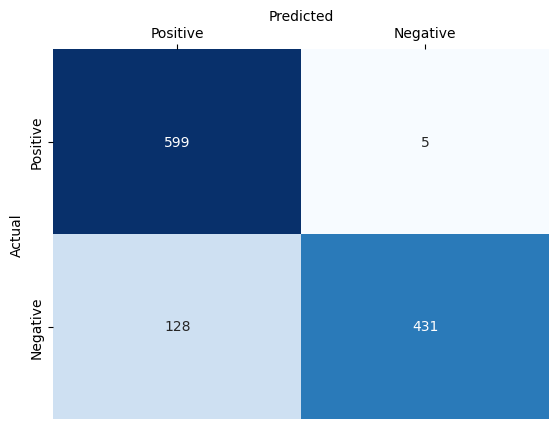

In [18]:
import time
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []
inference_times = []

with torch.no_grad():
    for feats, lengths, labels in test_loader:
        feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = model(feats, lengths)
        torch.cuda.synchronize()
        end = time.perf_counter()
        inference_times.append(end - start)

        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

print("Test accuracy:", correct / total)

import numpy as np

total_time = sum(inference_times)
avg_batch_time = np.mean(inference_times)
avg_sample_time = total_time / total  # total = number of samples

print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()  

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
ax.set_xlabel('Predicted')
ax.xaxis.set_label_position('top')
ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
# move ticks and labels to top of plot
ax.set_ylabel('Actual')


In [23]:

_, _, X_test_fish,  y_test_fish = get_sets(train_set="default", test_set="fish")
test_ds  = AudioListDataset(X_test_fish,  y_test_fish)
test_loader_fish  = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)



LOADING TRAINING DATA (Full Dataset)
ℹ️  Using entire AI/Human Voice datasets for training
   (No train/test split needed - testing on Fish dataset)

AI Voice Dataset:
  Total samples: 2404
  Unique speakers (voiceID): 31
  Unique dialects: 9
  Using ALL samples for training

Human Voice Dataset:
  Total samples: 2997
  Unique podcasts: 45
  Unique dialects: 9
  Using ALL samples for training

Loading training audio files...

Total training samples: 5401 (no augmentation)

LOADING TEST DATA (Fish Speech Dataset)

Reading CSV: /home/f25mlteam5/Project/External Dataset/fish_clean_detailed.csv
Total samples in fish_clean_detailed.csv: 6521
  Bonafide (label=0): 3459
  Spoofed (label=1): 3062

ℹ️  Using entire Fish dataset for testing
   (No split needed - trained on Default dataset)

Loading audio files...
Total test samples loaded: 6521

DATASET SUMMARY
Training samples: 5401
  AI (label=1): 2404
  Human (label=0): 2997

Test samples: 6521
  AI/Spoofed (label=1): 3062
  Human/Bonafide (l

Test accuracy: 0.5485355006900782
Average batch inference time: 0.011828 seconds
Average per-sample inference time: 0.000740 seconds


Text(50.722222222222214, 0.5, 'Actual')

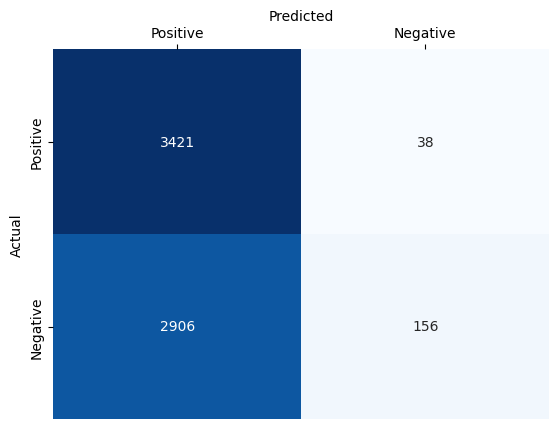

In [24]:
import time
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []
inference_times = []

with torch.no_grad():
    for feats, lengths, labels in test_loader_fish:
        feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = model(feats, lengths)
        torch.cuda.synchronize()
        end = time.perf_counter()
        inference_times.append(end - start)

        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

print("Test accuracy:", correct / total)

import numpy as np

total_time = sum(inference_times)
avg_batch_time = np.mean(inference_times)
avg_sample_time = total_time / total  # total = number of samples

print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()  

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
ax.set_xlabel('Predicted')
ax.xaxis.set_label_position('top')
ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
# move ticks and labels to top of plot
ax.set_ylabel('Actual')


In [26]:
X_train_fish, y_train_fish, X_test_fish,  y_test_fish = get_sets(train_set="fish", test_set="fish")

train_ds  = AudioListDataset(X_train_fish,  y_train_fish)

train_loader_fish = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)

test_ds  = AudioListDataset(X_test_fish,  y_test_fish)
test_loader_fish  = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)




LOADING TRAINING DATA (Fish Speech Dataset)

Reading CSV: /home/f25mlteam5/Project/External Dataset/fish_clean_detailed.csv
Total samples in fish_clean_detailed.csv: 6521
  Bonafide (label=0): 3459
  Spoofed (label=1): 3062
  Unique sources: 3523
  Unique dialects: 8

Performing source (speaker)-level split...
  Train sources: 2818 → 5220 samples
    Bonafide: 2765
    Spoofed: 2455
  Test sources: 705 → 1301 samples
    Bonafide: 694
    Spoofed: 607

Loading training audio files...

Total training samples: 5220 (no augmentation)

Loading test audio files from fish split...

DATASET SUMMARY
Training samples: 5220
  AI (label=1): 2455
  Human (label=0): 2765

Test samples: 1301
  AI/Spoofed (label=1): 607
  Human/Bonafide (label=0): 694



In [28]:


model = ConformerClassifier(
    num_classes=2,
    input_dim=80,
    encoder_dim=128,
    num_encoder_layers=4,
).to(device)

from tqdm import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

for epoch in tqdm(range(5)):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for feats, lengths, labels in train_loader_fish:
        feats = feats.to(device)          # [B, T, 80]
        lengths = lengths.to(device)      # [B]
        labels = labels.to(device)        # [B]

        optimizer.zero_grad()
        logits = model(feats, lengths)    # [B, 2]

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | "
          f"loss={running_loss/total:.4f} | "
          f"acc={correct/total:.4f}")


 20%|██        | 1/5 [00:17<01:10, 17.72s/it]

Epoch 1 | loss=0.6932 | acc=0.5557


 40%|████      | 2/5 [00:35<00:53, 17.79s/it]

Epoch 2 | loss=0.6184 | acc=0.6548


 60%|██████    | 3/5 [00:53<00:35, 17.84s/it]

Epoch 3 | loss=0.4930 | acc=0.7632


 80%|████████  | 4/5 [01:11<00:17, 17.92s/it]

Epoch 4 | loss=0.3529 | acc=0.8446


100%|██████████| 5/5 [01:29<00:00, 17.89s/it]

Epoch 5 | loss=0.2629 | acc=0.8887


Test accuracy: 0.9285165257494236
Average batch inference time: 0.011892 seconds
Average per-sample inference time: 0.000750 seconds


Text(50.722222222222214, 0.5, 'Actual')

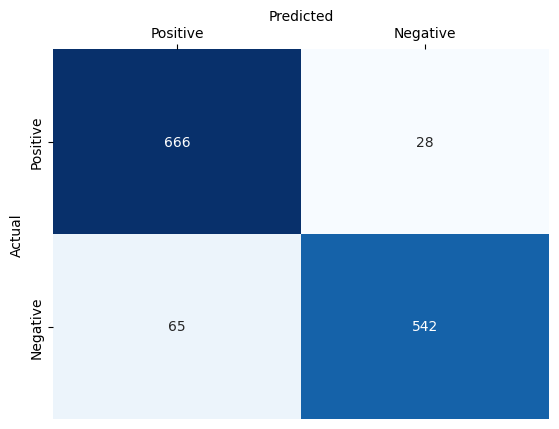

: 

In [ ]:
import time
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []
inference_times = []

with torch.no_grad():
    for feats, lengths, labels in test_loader_fish:
        feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = model(feats, lengths)
        torch.cuda.synchronize()
        end = time.perf_counter()
        inference_times.append(end - start)

        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

print("Test accuracy:", correct / total)

import numpy as np

total_time = sum(inference_times)
avg_batch_time = np.mean(inference_times)
avg_sample_time = total_time / total  # total = number of samples

print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()  

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
ax.set_xlabel('Predicted')
ax.xaxis.set_label_position('top')
ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
# move ticks and labels to top of plot
ax.set_ylabel('Actual')


In [9]:
%matplotlib inline


Holding Out: ['Bahraini', 'Egyptian', 'Emarati'], Training On: ['Lebanese', 'Palestinian', 'Jordanian', 'Saudi', 'Iraqi', 'Syrian']
LOADING TRAINING DATA (Custom Dialect Split)

AI Voice Dataset:
  Total samples: 2404
  Available dialects: 9
  Train dialects (specified): 6 → 1572 samples
    Dialects: ['Iraqi', 'Jordanian', 'Lebanese', 'Palestinian', 'Saudi', 'Syrian']
  Test dialects (inferred): 3 → 832 samples
    Dialects: ['Bahraini', 'Egyptian', 'Emarati']

Human Voice Dataset:
  Total samples: 2997
  Available dialects: 9
  Train dialects (specified): 6 → 1998 samples
    Dialects: ['Iraqi', 'Jordanian', 'Lebanese', 'Palestinian', 'Saudi', 'Syrian']
  Test dialects (inferred): 3 → 999 samples
    Dialects: ['Bahraini', 'Egyptian', 'Emarati']

Loading training audio files...

Total training samples: 3570 (no augmentation)

Loading test audio files from default split...

Total test samples: 1831

DATASET SUMMARY
Training samples: 3570
  AI (label=1): 1572
  Human (label=0): 1998

T

 20%|██        | 1/5 [00:20<01:22, 20.70s/it]

Epoch 1 | loss=0.4654 | acc=0.7739


 40%|████      | 2/5 [00:41<01:02, 20.79s/it]

Epoch 2 | loss=0.1327 | acc=0.9602


...

 80%|████████  | 4/5 [01:23<00:20, 20.74s/it]

Epoch 4 | loss=0.0503 | acc=0.9846


100%|██████████| 5/5 [01:43<00:00, 20.74s/it]

Epoch 5 | loss=0.0376 | acc=0.9860
Training done


Test accuracy: 0.7067176406335336
Average batch inference time: 0.019024 seconds
Average per-sample inference time: 0.001195 seconds


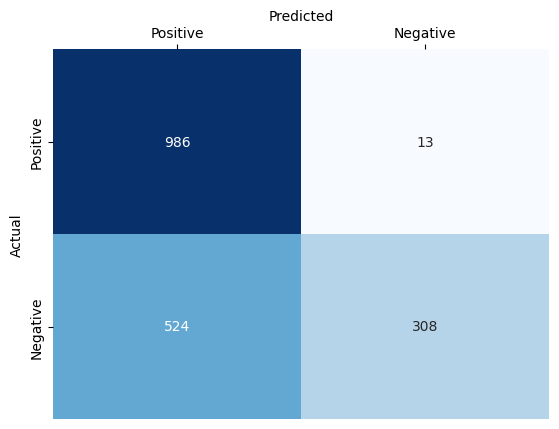

Holding Out: ['Iraqi', 'Jordanian', 'Lebanese'], Training On: ['Egyptian', 'Palestinian', 'Emarati', 'Bahraini', 'Saudi', 'Syrian']
LOADING TRAINING DATA (Custom Dialect Split)

AI Voice Dataset:
  Total samples: 2404
  Available dialects: 9
  Train dialects (specified): 6 → 1592 samples
    Dialects: ['Bahraini', 'Egyptian', 'Emarati', 'Palestinian', 'Saudi', 'Syrian']
  Test dialects (inferred): 3 → 812 samples
    Dialects: ['Iraqi', 'Jordanian', 'Lebanese']

Human Voice Dataset:
  Total samples: 2997
  Available dialects: 9
  Train dialects (specified): 6 → 1998 samples
    Dialects: ['Bahraini', 'Egyptian', 'Emarati', 'Palestinian', 'Saudi', 'Syrian']
  Test dialects (inferred): 3 → 999 samples
    Dialects: ['Iraqi', 'Jordanian', 'Lebanese']

Loading training audio files...

Total training samples: 3590 (no augmentation)

Loading test audio files from default split...

Total test samples: 1811

DATASET SUMMARY
Training samples: 3590
  AI (label=1): 1592
  Human (label=0): 1998

T

 20%|██        | 1/5 [00:20<01:22, 20.58s/it]

Epoch 1 | loss=0.5035 | acc=0.7535


 40%|████      | 2/5 [00:41<01:02, 20.81s/it]

Epoch 2 | loss=0.2076 | acc=0.9203


...

 80%|████████  | 4/5 [01:23<00:21, 21.07s/it]

Epoch 4 | loss=0.0899 | acc=0.9691


100%|██████████| 5/5 [01:45<00:00, 21.01s/it]

Epoch 5 | loss=0.0486 | acc=0.9830
Training done


Test accuracy: 0.8658199889563777
Average batch inference time: 0.019336 seconds
Average per-sample inference time: 0.001217 seconds


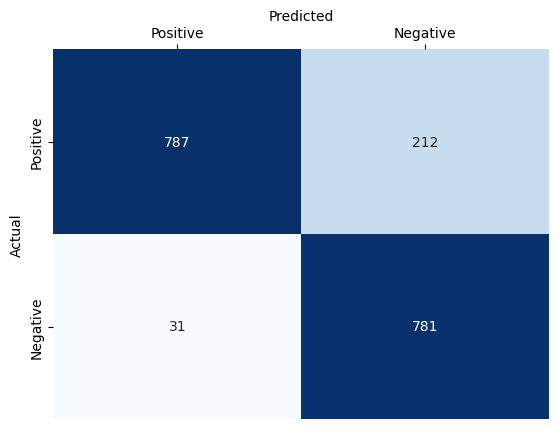

Holding Out: ['Palestinian', 'Saudi', 'Syrian'], Training On: ['Egyptian', 'Lebanese', 'Emarati', 'Jordanian', 'Bahraini', 'Iraqi']
LOADING TRAINING DATA (Custom Dialect Split)

AI Voice Dataset:
  Total samples: 2404
  Available dialects: 9
  Train dialects (specified): 6 → 1644 samples
    Dialects: ['Bahraini', 'Egyptian', 'Emarati', 'Iraqi', 'Jordanian', 'Lebanese']
  Test dialects (inferred): 3 → 760 samples
    Dialects: ['Palestinian', 'Saudi', 'Syrian']

Human Voice Dataset:
  Total samples: 2997
  Available dialects: 9
  Train dialects (specified): 6 → 1998 samples
    Dialects: ['Bahraini', 'Egyptian', 'Emarati', 'Iraqi', 'Jordanian', 'Lebanese']
  Test dialects (inferred): 3 → 999 samples
    Dialects: ['Palestinian', 'Saudi', 'Syrian']

Loading training audio files...

Total training samples: 3642 (no augmentation)

Loading test audio files from default split...

Total test samples: 1759

DATASET SUMMARY
Training samples: 3642
  AI (label=1): 1644
  Human (label=0): 1998

T

 20%|██        | 1/5 [00:21<01:26, 21.52s/it]

Epoch 1 | loss=0.4075 | acc=0.8040


 40%|████      | 2/5 [00:43<01:04, 21.55s/it]

Epoch 2 | loss=0.1575 | acc=0.9421


...

 80%|████████  | 4/5 [01:25<00:21, 21.48s/it]

Epoch 4 | loss=0.0560 | acc=0.9827


100%|██████████| 5/5 [01:46<00:00, 21.33s/it]

Epoch 5 | loss=0.0470 | acc=0.9846
Training done


Test accuracy: 0.8555997725980671
Average batch inference time: 0.019243 seconds
Average per-sample inference time: 0.001203 seconds


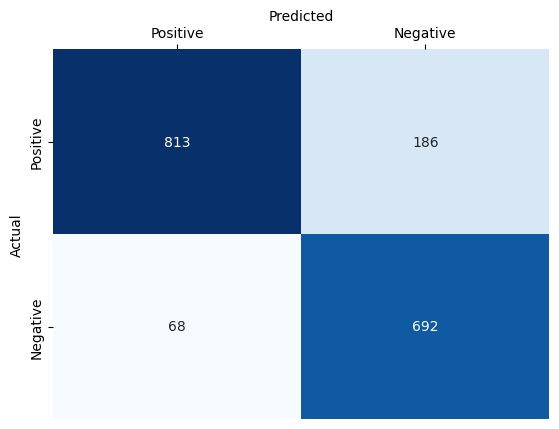

In [ ]:
"""
Our Dataset 3-fold Dialect Hold Out
"""
dialects = ["Bahraini",  "Egyptian",  "Emarati", "Iraqi",  "Jordanian",  "Lebanese", "Palestinian",  "Saudi", "Syrian"]

hold_out_folds = [
    ["Bahraini", "Egyptian", "Emarati"],
    ["Iraqi", "Jordanian", "Lebanese"],
    ["Palestinian", "Saudi", "Syrian"]
]

for test_dialects in hold_out_folds:
    print("Holding Out:", test_dialects, end=', ')
    train_dialects = list(set(dialects) - set(test_dialects))
    print("Training On:", train_dialects,)

    X_train, y_train, X_test, y_test = get_sets(train_set="default", test_set="default", split_method={"train": train_dialects})
    train_loader = DataLoader(AudioListDataset(X_train,  y_train), batch_size=16, shuffle=True, collate_fn=collate_fn)
    test_loader  = DataLoader(AudioListDataset(X_test,  y_test), batch_size=16, shuffle=False, collate_fn=collate_fn)

    model = ConformerClassifier(
        num_classes=2,
        input_dim=80,
        encoder_dim=128,
        num_encoder_layers=4,
    ).to(device)

    from tqdm import tqdm
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    print("Training for 5 epochs")
    for epoch in tqdm(range(5)):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for feats, lengths, labels in train_loader:
            feats = feats.to(device)          # [B, T, 80]
            lengths = lengths.to(device)      # [B]
            labels = labels.to(device)        # [B]

            optimizer.zero_grad()
            logits = model(feats, lengths)    # [B, 2]

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        print(f"Epoch {epoch+1} | "
            f"loss={running_loss/total:.4f} | "
            f"acc={correct/total:.4f}")
        
    print("Training done")

    import time
    model.eval()
    correct = 0
    total = 0
    y_pred = []
    y_true = []
    inference_times = []

    with torch.no_grad():
        for feats, lengths, labels in test_loader:
            feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
            torch.cuda.synchronize()
            start = time.perf_counter()
            logits = model(feats, lengths)
            torch.cuda.synchronize()
            end = time.perf_counter()
            inference_times.append(end - start)

            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            y_pred.extend(preds.cpu().tolist())
            y_true.extend(labels.cpu().tolist())

    print("Test accuracy:", correct / total)

    import numpy as np

    total_time = sum(inference_times)
    avg_batch_time = np.mean(inference_times)
    avg_sample_time = total_time / total  # total = number of samples

    print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
    print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


    from sklearn.metrics import confusion_matrix
    matrix = confusion_matrix(y_true, y_pred)

    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, ax = plt.subplots()  

    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
    ax.set_xlabel('Predicted')
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
    # move ticks and labels to top of plot
    ax.set_ylabel('Actual')
    plt.show()

    print("=" * 80)
    plt.close()



Holding Out: ['Algerian', 'Egyptian', 'Jordanian'], Training On: ['Yemeni', 'Palestinian', 'Moroccan', 'Emarati', 'Mauritanian']
LOADING TRAINING DATA (Fish Speech Dataset)

Reading CSV: /home/f25mlteam5/Project/External Dataset/fish_clean_detailed.csv
Total samples in fish_clean_detailed.csv: 6521
  Bonafide (label=0): 3459
  Spoofed (label=1): 3062
  Unique sources: 3523
  Unique dialects: 8

Performing custom dialect-level split...
  Train dialects (specified): 5 → 4091 samples
    Dialects: ['Emarati', 'Mauritanian', 'Moroccan', 'Palestinian', 'Yemeni']
    Bonafide: 2105
    Spoofed: 1986
  Test dialects (inferred): 3 → 2430 samples
    Dialects: ['Algerian', 'Egyptian', 'Jordanian']
    Bonafide: 1354
    Spoofed: 1076

Loading training audio files...

Total training samples: 4091 (no augmentation)

Loading test audio files from fish split...

DATASET SUMMARY
Training samples: 4091
  AI (label=1): 1986
  Human (label=0): 2105

Test samples: 2430
  AI/Spoofed (label=1): 1076
  Hum

 20%|██        | 1/5 [00:27<01:49, 27.35s/it]

Epoch 1 | loss=0.7009 | acc=0.5456


 40%|████      | 2/5 [00:53<01:20, 26.69s/it]

Epoch 2 | loss=0.6193 | acc=0.6551


...

 80%|████████  | 4/5 [01:47<00:26, 26.80s/it]

Epoch 4 | loss=0.4233 | acc=0.8069


100%|██████████| 5/5 [02:13<00:00, 26.80s/it]

Epoch 5 | loss=0.3106 | acc=0.8687
Training done


Test accuracy: 0.7041152263374486
Average batch inference time: 0.019340 seconds
Average per-sample inference time: 0.001210 seconds


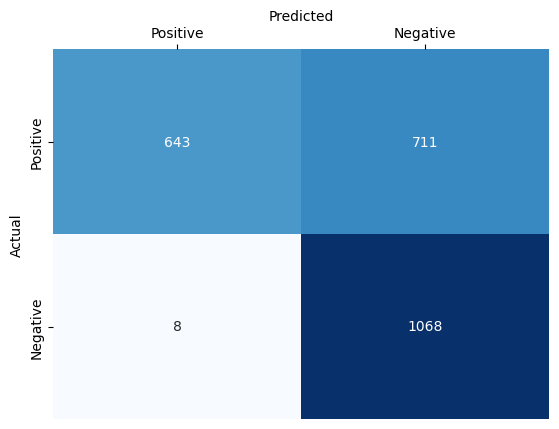

In [6]:
"""
ArFake (Fish) 3-fold Dialect Hold Out
"""

dialects = ["Algerian",  "Egyptian",  "Jordanian",  "Mauritanian",  "Moroccan",  "Palestinian",  "Emarati",  "Yemeni",]

hold_out_folds = [
    ["Algerian", "Egyptian", "Jordanian"],
    ["Mauritanian", "Moroccan", "Palestinian"],
    ["Emarati", "Yemeni"]
]

test_dialects = hold_out_folds[0]
print("Holding Out:", test_dialects, end=', ')
train_dialects = list(set(dialects) - set(test_dialects))
print("Training On:", train_dialects,)

X_train, y_train, X_test, y_test = get_sets(train_set="fish", test_set="fish", split_method={"train": train_dialects})
train_loader = DataLoader(AudioListDataset(X_train,  y_train), batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(AudioListDataset(X_test,  y_test), batch_size=16, shuffle=False, collate_fn=collate_fn)

model = ConformerClassifier(
    num_classes=2,
    input_dim=80,
    encoder_dim=128,
    num_encoder_layers=4,
).to(device)

from tqdm import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

print("Training for 5 epochs")
for epoch in tqdm(range(5)):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for feats, lengths, labels in train_loader:
        feats = feats.to(device)          # [B, T, 80]
        lengths = lengths.to(device)      # [B]
        labels = labels.to(device)        # [B]

        optimizer.zero_grad()
        logits = model(feats, lengths)    # [B, 2]

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | "
        f"loss={running_loss/total:.4f} | "
        f"acc={correct/total:.4f}")
    
print("Training done")

import time
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []
inference_times = []

with torch.no_grad():
    for feats, lengths, labels in test_loader:
        feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = model(feats, lengths)
        torch.cuda.synchronize()
        end = time.perf_counter()
        inference_times.append(end - start)

        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

print("Test accuracy:", correct / total)

import numpy as np

total_time = sum(inference_times)
avg_batch_time = np.mean(inference_times)
avg_sample_time = total_time / total  # total = number of samples

print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()  

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
ax.set_xlabel('Predicted')
ax.xaxis.set_label_position('top')
ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
# move ticks and labels to top of plot
ax.set_ylabel('Actual')
plt.show()

print("=" * 80)
plt.close()



Holding Out: ['Mauritanian', 'Moroccan', 'Palestinian'], Training On: ['Algerian', 'Jordanian', 'Emarati', 'Yemeni', 'Egyptian']
LOADING TRAINING DATA (Fish Speech Dataset)

Reading CSV: /home/f25mlteam5/Project/External Dataset/fish_clean_detailed.csv
Total samples in fish_clean_detailed.csv: 6521
  Bonafide (label=0): 3459
  Spoofed (label=1): 3062
  Unique sources: 3523
  Unique dialects: 8

Performing custom dialect-level split...
  Train dialects (specified): 5 → 4254 samples
    Dialects: ['Algerian', 'Egyptian', 'Emarati', 'Jordanian', 'Yemeni']
    Bonafide: 2315
    Spoofed: 1939
  Test dialects (inferred): 3 → 2267 samples
    Dialects: ['Mauritanian', 'Moroccan', 'Palestinian']
    Bonafide: 1144
    Spoofed: 1123

Loading training audio files...

Total training samples: 4254 (no augmentation)

Loading test audio files from fish split...

DATASET SUMMARY
Training samples: 4254
  AI (label=1): 1939
  Human (label=0): 2315

Test samples: 2267
  AI/Spoofed (label=1): 1123
  Hum

 20%|██        | 1/5 [00:27<01:50, 27.68s/it]

Epoch 1 | loss=0.6824 | acc=0.5762


 40%|████      | 2/5 [00:54<01:21, 27.26s/it]

Epoch 2 | loss=0.5997 | acc=0.6787


...

 80%|████████  | 4/5 [01:48<00:27, 27.13s/it]

Epoch 4 | loss=0.3290 | acc=0.8568


100%|██████████| 5/5 [02:15<00:00, 27.14s/it]

Epoch 5 | loss=0.2441 | acc=0.9001
Training done


Test accuracy: 0.8244375827084253
Average batch inference time: 0.018116 seconds
Average per-sample inference time: 0.001135 seconds


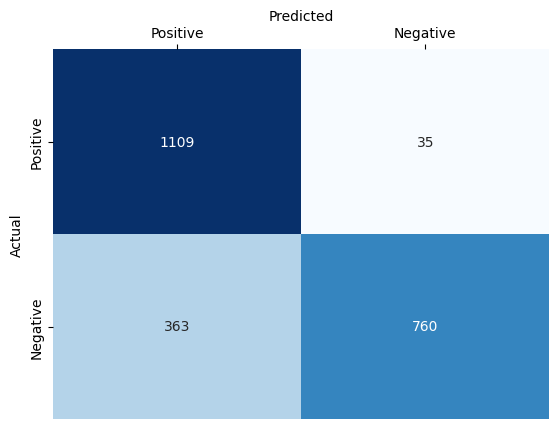

In [6]:
"""
ArFake (Fish) 3-fold Dialect Hold Out
"""

dialects = ["Algerian",  "Egyptian",  "Jordanian",  "Mauritanian",  "Moroccan",  "Palestinian",  "Emarati",  "Yemeni",]

hold_out_folds = [
    ["Algerian", "Egyptian", "Jordanian"],
    ["Mauritanian", "Moroccan", "Palestinian"],
    ["Emarati", "Yemeni"]
]

test_dialects = hold_out_folds[1]
print("Holding Out:", test_dialects, end=', ')
train_dialects = list(set(dialects) - set(test_dialects))
print("Training On:", train_dialects,)

X_train, y_train, X_test, y_test = get_sets(train_set="fish", test_set="fish", split_method={"train": train_dialects})
train_loader = DataLoader(AudioListDataset(X_train,  y_train), batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(AudioListDataset(X_test,  y_test), batch_size=16, shuffle=False, collate_fn=collate_fn)

model = ConformerClassifier(
    num_classes=2,
    input_dim=80,
    encoder_dim=128,
    num_encoder_layers=4,
).to(device)

from tqdm import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

print("Training for 5 epochs")
for epoch in tqdm(range(5)):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for feats, lengths, labels in train_loader:
        feats = feats.to(device)          # [B, T, 80]
        lengths = lengths.to(device)      # [B]
        labels = labels.to(device)        # [B]

        optimizer.zero_grad()
        logits = model(feats, lengths)    # [B, 2]

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | "
        f"loss={running_loss/total:.4f} | "
        f"acc={correct/total:.4f}")
    
print("Training done")

import time
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []
inference_times = []

with torch.no_grad():
    for feats, lengths, labels in test_loader:
        feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = model(feats, lengths)
        torch.cuda.synchronize()
        end = time.perf_counter()
        inference_times.append(end - start)

        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

print("Test accuracy:", correct / total)

import numpy as np

total_time = sum(inference_times)
avg_batch_time = np.mean(inference_times)
avg_sample_time = total_time / total  # total = number of samples

print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()  

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
ax.set_xlabel('Predicted')
ax.xaxis.set_label_position('top')
ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
# move ticks and labels to top of plot
ax.set_ylabel('Actual')
plt.show()

print("=" * 80)
plt.close()



Holding Out: ['Emarati', 'Yemeni'], Training On: ['Moroccan', 'Jordanian', 'Mauritanian', 'Algerian', 'Palestinian', 'Egyptian']
LOADING TRAINING DATA (Fish Speech Dataset)

Reading CSV: /home/f25mlteam5/Project/External Dataset/fish_clean_detailed.csv
Total samples in fish_clean_detailed.csv: 6521
  Bonafide (label=0): 3459
  Spoofed (label=1): 3062
  Unique sources: 3523
  Unique dialects: 8

Performing custom dialect-level split...
  Train dialects (specified): 6 → 4697 samples
    Dialects: ['Algerian', 'Egyptian', 'Jordanian', 'Mauritanian', 'Moroccan', 'Palestinian']
    Bonafide: 2498
    Spoofed: 2199
  Test dialects (inferred): 2 → 1824 samples
    Dialects: ['Emarati', 'Yemeni']
    Bonafide: 961
    Spoofed: 863

Loading training audio files...

Total training samples: 4697 (no augmentation)

Loading test audio files from fish split...

DATASET SUMMARY
Training samples: 4697
  AI (label=1): 2199
  Human (label=0): 2498

Test samples: 1824
  AI/Spoofed (label=1): 863
  Human/

 20%|██        | 1/5 [00:30<02:01, 30.37s/it]

Epoch 1 | loss=0.6603 | acc=0.6025


 40%|████      | 2/5 [00:59<01:29, 29.93s/it]

Epoch 2 | loss=0.5309 | acc=0.7307


...

 80%|████████  | 4/5 [01:58<00:29, 29.66s/it]

Epoch 4 | loss=0.2495 | acc=0.8963


100%|██████████| 5/5 [02:28<00:00, 29.69s/it]

Epoch 5 | loss=0.1901 | acc=0.9251
Training done


Test accuracy: 0.8294956140350878
Average batch inference time: 0.019337 seconds
Average per-sample inference time: 0.001209 seconds


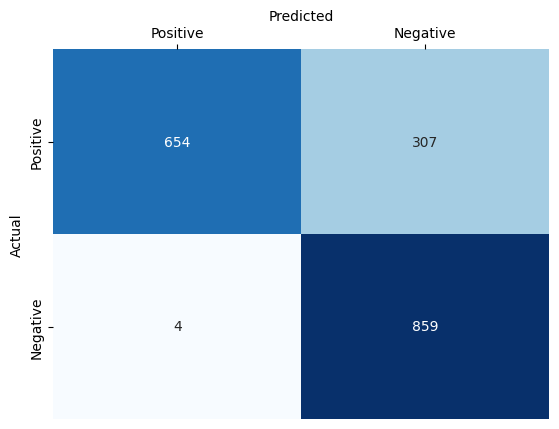

In [6]:
"""
ArFake (Fish) 3-fold Dialect Hold Out
"""

dialects = ["Algerian",  "Egyptian",  "Jordanian",  "Mauritanian",  "Moroccan",  "Palestinian",  "Emarati",  "Yemeni",]

hold_out_folds = [
    ["Algerian", "Egyptian", "Jordanian"],
    ["Mauritanian", "Moroccan", "Palestinian"],
    ["Emarati", "Yemeni"]
]

test_dialects = hold_out_folds[2]
print("Holding Out:", test_dialects, end=', ')
train_dialects = list(set(dialects) - set(test_dialects))
print("Training On:", train_dialects,)

X_train, y_train, X_test, y_test = get_sets(train_set="fish", test_set="fish", split_method={"train": train_dialects})
train_loader = DataLoader(AudioListDataset(X_train,  y_train), batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(AudioListDataset(X_test,  y_test), batch_size=16, shuffle=False, collate_fn=collate_fn)

model = ConformerClassifier(
    num_classes=2,
    input_dim=80,
    encoder_dim=128,
    num_encoder_layers=4,
).to(device)

from tqdm import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

print("Training for 5 epochs")
for epoch in tqdm(range(5)):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for feats, lengths, labels in train_loader:
        feats = feats.to(device)          # [B, T, 80]
        lengths = lengths.to(device)      # [B]
        labels = labels.to(device)        # [B]

        optimizer.zero_grad()
        logits = model(feats, lengths)    # [B, 2]

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | "
        f"loss={running_loss/total:.4f} | "
        f"acc={correct/total:.4f}")
    
print("Training done")

import time
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []
inference_times = []

with torch.no_grad():
    for feats, lengths, labels in test_loader:
        feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = model(feats, lengths)
        torch.cuda.synchronize()
        end = time.perf_counter()
        inference_times.append(end - start)

        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

print("Test accuracy:", correct / total)

import numpy as np

total_time = sum(inference_times)
avg_batch_time = np.mean(inference_times)
avg_sample_time = total_time / total  # total = number of samples

print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()  

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
ax.set_xlabel('Predicted')
ax.xaxis.set_label_position('top')
ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
# move ticks and labels to top of plot
ax.set_ylabel('Actual')
plt.show()

print("=" * 80)
plt.close()



In [6]:
common_dialects = ['Egyptian', 'Jordanian', 'Palestinian', 'Emarati'] 


X_train, y_train, X_test, y_test = get_sets(train_set="both", test_set="default", split_method={"train": common_dialects})


train_loader_combined = DataLoader(AudioListDataset(X_train,  y_train), batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(AudioListDataset(X_test,  y_test), batch_size=16, shuffle=False, collate_fn=collate_fn)




LOADING TRAINING DATA (Both Datasets)

Default datasets loaded:
  AI Voice: 2404 samples
  Human Voice: 2997 samples

Fish dataset loaded: 6521 samples

Validating custom dialect split across both datasets...
  ✓ All specified dialects exist in all datasets

------------------------------------------------------------
Strategy: Split default, train on (default_train + all_fish)
------------------------------------------------------------

Splitting DEFAULT datasets (Custom Dialect)...
  AI: 1022 train, 1382 test
  Human: 1332 train, 1665 test
  Fish (filtered): 3588 train samples

Loading audio files...

Combined training: 5942 samples
Test (default only): 3047 samples

Total training samples: 5942 (no augmentation)

Total test samples: 3047

DATASET SUMMARY
Training samples: 5942
  AI (label=1): 2672
  Human (label=0): 3270

Test samples: 3047
  AI/Spoofed (label=1): 1382
  Human/Bonafide (label=0): 1665



Training for 5 epochs


 14%|█▍        | 1/7 [00:21<02:08, 21.34s/it]

Epoch 1 | loss=0.6223 | acc=0.6537


 29%|██▊       | 2/7 [00:42<01:47, 21.50s/it]

Epoch 2 | loss=0.4937 | acc=0.7644


...

 86%|████████▌ | 6/7 [02:07<00:21, 21.20s/it]

Epoch 6 | loss=0.1580 | acc=0.9354


100%|██████████| 7/7 [02:28<00:00, 21.22s/it]

Epoch 7 | loss=0.1093 | acc=0.9606
Training done


Test accuracy: 0.8726616343944864
Average batch inference time: 0.009036 seconds
Average per-sample inference time: 0.000566 seconds


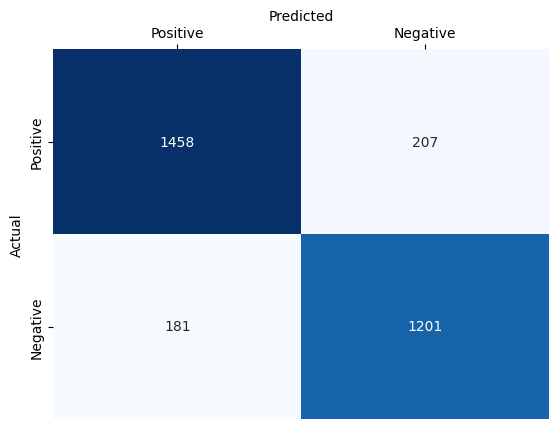

In [9]:
model = ConformerClassifier(
    num_classes=2,
    input_dim=80,
    encoder_dim=128,
    num_encoder_layers=4,
).to(device)

from tqdm import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

print("Training for 5 epochs")
for epoch in tqdm(range(7)):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for feats, lengths, labels in train_loader_combined:
        feats = feats.to(device)          # [B, T, 80]
        lengths = lengths.to(device)      # [B]
        labels = labels.to(device)        # [B]

        optimizer.zero_grad()
        logits = model(feats, lengths)    # [B, 2]

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | "
        f"loss={running_loss/total:.4f} | "
        f"acc={correct/total:.4f}")
    
print("Training done")

import time
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []
inference_times = []

with torch.no_grad():
    for feats, lengths, labels in test_loader:
        feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = model(feats, lengths)
        torch.cuda.synchronize()
        end = time.perf_counter()
        inference_times.append(end - start)

        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

print("Test accuracy:", correct / total)

import numpy as np

total_time = sum(inference_times)
avg_batch_time = np.mean(inference_times)
avg_sample_time = total_time / total  # total = number of samples

print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()  

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
ax.set_xlabel('Predicted')
ax.xaxis.set_label_position('top')
ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
# move ticks and labels to top of plot
ax.set_ylabel('Actual')
plt.show()

In [6]:
common_dialects = ['Egyptian', 'Jordanian', 'Palestinian', 'Emarati'] 

X_train, y_train, X_test, y_test = get_sets(train_set="both", test_set="fish", split_method={"train": common_dialects})


train_loader_combined = DataLoader(AudioListDataset(X_train,  y_train), batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(AudioListDataset(X_test,  y_test), batch_size=16, shuffle=False, collate_fn=collate_fn)





LOADING TRAINING DATA (Both Datasets)

Default datasets loaded:
  AI Voice: 2404 samples
  Human Voice: 2997 samples

Fish dataset loaded: 6521 samples

Validating custom dialect split across both datasets...
  ✓ All specified dialects exist in all datasets

------------------------------------------------------------
Strategy: Split fish, train on (fish_train + all_default)
------------------------------------------------------------

Splitting FISH dataset (custom dialect)...
  Fish: 3588 train, 2933 test
  AI (filtered): 1022 train samples
  Human (filtered): 1332 train samples

Loading audio files...

Combined training: 5942 samples
Test (fish only): 2933 samples

Total training samples: 5942 (no augmentation)

DATASET SUMMARY
Training samples: 5942
  AI (label=1): 2672
  Human (label=0): 3270

Test samples: 2933
  AI/Spoofed (label=1): 1412
  Human/Bonafide (label=0): 1521



Training for 5 epochs


 14%|█▍        | 1/7 [00:38<03:48, 38.15s/it]

Epoch 1 | loss=0.6153 | acc=0.6587


 29%|██▊       | 2/7 [01:15<03:07, 37.46s/it]

Epoch 2 | loss=0.4621 | acc=0.7848


...

 86%|████████▌ | 6/7 [03:44<00:37, 37.41s/it]

Epoch 6 | loss=0.1342 | acc=0.9478


100%|██████████| 7/7 [04:22<00:00, 37.48s/it]

Epoch 7 | loss=0.1007 | acc=0.9642
Training done


Test accuracy: 0.9287419024889192
Average batch inference time: 0.016487 seconds
Average per-sample inference time: 0.001034 seconds


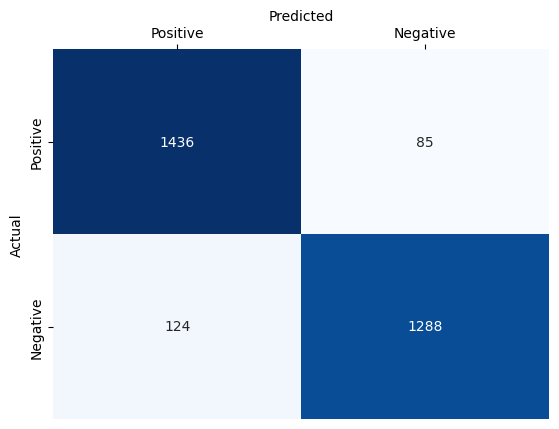

In [7]:
model = ConformerClassifier(
    num_classes=2,
    input_dim=80,
    encoder_dim=128,
    num_encoder_layers=4,
).to(device)

from tqdm import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

print("Training for 5 epochs")
for epoch in tqdm(range(7)):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for feats, lengths, labels in train_loader_combined:
        feats = feats.to(device)          # [B, T, 80]
        lengths = lengths.to(device)      # [B]
        labels = labels.to(device)        # [B]

        optimizer.zero_grad()
        logits = model(feats, lengths)    # [B, 2]

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | "
        f"loss={running_loss/total:.4f} | "
        f"acc={correct/total:.4f}")
    
print("Training done")

import time
model.eval()
correct = 0
total = 0
y_pred = []
y_true = []
inference_times = []

with torch.no_grad():
    for feats, lengths, labels in test_loader:
        feats, lengths, labels = feats.to(device), lengths.to(device), labels.to(device)
        torch.cuda.synchronize()
        start = time.perf_counter()
        logits = model(feats, lengths)
        torch.cuda.synchronize()
        end = time.perf_counter()
        inference_times.append(end - start)

        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

print("Test accuracy:", correct / total)

import numpy as np

total_time = sum(inference_times)
avg_batch_time = np.mean(inference_times)
avg_sample_time = total_time / total  # total = number of samples

print(f"Average batch inference time: {avg_batch_time:.6f} seconds")
print(f"Average per-sample inference time: {avg_sample_time:.6f} seconds")


from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()  

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
ax.set_xlabel('Predicted')
ax.xaxis.set_label_position('top')
ax.xaxis.set_tick_params(labeltop=True, top=True, labelbottom=False, bottom=False)
# move ticks and labels to top of plot
ax.set_ylabel('Actual')
plt.show()